# MindStride — EEG Motor Imagery Classification (Fixed)

## Cross-subject EEGNet with subject-based split, CV & grid search

### Fixes applied vs. original notebook:
1. **Removed double-CSP pipeline** — was stacking two CSPs sequentially (broken)
2. **Fixed early stopping on test set** — final models no longer use test set for model selection
3. **Fixed preprocessing grid search leakage** — held-out test subjects are now excluded from preprocessing search
4. **Fixed inconsistent subject splits** — single global split used for fair comparison across all approaches
5. **Fixed augmentation code** — numpy/torch type mismatch, wrap-around artifacts
6. **Added scheduler to CV** — results now comparable with single-run training
7. **Removed FBCSP section with broken pipeline** — placeholder left for proper implementation


In [39]:
# !pip uninstall torch torchvision torchaudio -y
# !pip install -U --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install mne kagglehub


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_class_weight
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from mne.decoding import CSP
from scipy import signal
from scipy.signal import welch
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm
import time
import random
import warnings
import math
import copy
import itertools
import mne
from pprint import pprint

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__)
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.12.0.dev20260316+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5080


In [41]:
# ============================================================
# Metrics Registry & Model Saving Utilities
# ============================================================
import os
import json
import joblib
from datetime import datetime
from collections import OrderedDict

SAVE_DIR = "models"
RESULTS_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Global registry — every experiment appends here
METRICS_REGISTRY = []

# Per-fold CV details (for later statistical analysis)
CV_DETAILS = {}


def register_result(experiment, approach, model_name, 
                    test_acc=None, test_loss=None,
                    cv_mean=None, cv_std=None, cv_folds=None,
                    precision=None, recall=None, f1=None,
                    confusion_mat=None, class_report_dict=None,
                    train_history=None, best_params=None,
                    n_train=None, n_test=None,
                    extra=None):
    """Register a result in the global metrics registry."""
    entry = {
        'timestamp': datetime.now().isoformat(),
        'experiment': experiment,       # e.g. '3class_64ch', 'binary_lr_21ch'
        'approach': approach,           # e.g. 'EEGNet', 'CSP+SVM', '2-stage'
        'model_name': model_name,       # specific identifier
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'cv_mean_accuracy': cv_mean,
        'cv_std_accuracy': cv_std,
        'cv_fold_accuracies': cv_folds,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'confusion_matrix': confusion_mat.tolist() if confusion_mat is not None else None,
        'classification_report': class_report_dict,
        'train_history': train_history,
        'best_params': best_params,
        'n_train_epochs': n_train,
        'n_test_epochs': n_test,
    }
    if extra:
        entry.update(extra)
    METRICS_REGISTRY.append(entry)
    print(f"  📊 Registered: {experiment} / {approach} / {model_name} "
          f"→ test_acc={test_acc:.4f}" if test_acc else 
          f"  📊 Registered: {experiment} / {approach} / {model_name}")
    return entry


def save_nn_model(model, name, meta=None):
    """Save a PyTorch model + metadata."""
    path = os.path.join(SAVE_DIR, f"{name}.pth")
    torch.save(model.state_dict(), path)
    if meta:
        meta_path = os.path.join(SAVE_DIR, f"{name}_meta.json")
        with open(meta_path, 'w') as f:
            json.dump(meta, f, indent=2)
    print(f"  💾 Saved: {path}")
    return path


def save_sklearn_model(pipeline, name, meta=None):
    """Save a sklearn pipeline + metadata."""
    path = os.path.join(SAVE_DIR, f"{name}.pkl")
    joblib.dump(pipeline, path)
    if meta:
        meta_path = os.path.join(SAVE_DIR, f"{name}_meta.json")
        with open(meta_path, 'w') as f:
            json.dump(meta, f, indent=2)
    print(f"  💾 Saved: {path}")
    return path


def save_all_results():
    """Save the entire metrics registry to JSON and CSV."""
    # JSON (full detail)
    json_path = os.path.join(RESULTS_DIR, "all_metrics.json")
    with open(json_path, 'w') as f:
        json.dump(METRICS_REGISTRY, f, indent=2, default=str)
    
    # CSV (summary table)
    summary_rows = []
    for r in METRICS_REGISTRY:
        summary_rows.append({
            'experiment': r['experiment'],
            'approach': r['approach'],
            'model_name': r['model_name'],
            'test_accuracy': r.get('test_accuracy'),
            'test_loss': r.get('test_loss'),
            'cv_mean': r.get('cv_mean_accuracy'),
            'cv_std': r.get('cv_std_accuracy'),
            'n_train': r.get('n_train_epochs'),
            'n_test': r.get('n_test_epochs'),
        })
    summary_df = pd.DataFrame(summary_rows)
    csv_path = os.path.join(RESULTS_DIR, "summary_metrics.csv")
    summary_df.to_csv(csv_path, index=False)
    
    # CV details
    if CV_DETAILS:
        cv_path = os.path.join(RESULTS_DIR, "cv_details.json")
        with open(cv_path, 'w') as f:
            json.dump(CV_DETAILS, f, indent=2, default=str)
    
    print(f"\n📁 Results saved:")
    print(f"   {json_path}")
    print(f"   {csv_path}")
    if CV_DETAILS:
        print(f"   {os.path.join(RESULTS_DIR, 'cv_details.json')}")
    
    return summary_df


print("✅ Metrics registry & model saving ready")
print(f"   Models → {SAVE_DIR}/")
print(f"   Results → {RESULTS_DIR}/")


✅ Metrics registry & model saving ready
   Models → models/
   Results → results/


## 1. Data Loading — Motor Imagery runs only (R04, R08, R12)

From the PhysioNet EEG Motor Movement/Imagery Dataset:
- **R03, R07, R11** → Task 1: real movement (left/right fist)
- **R04, R08, R12** → Task 2: **motor imagery** (left/right fist) ← we use these
- R05, R09, R13 → Task 3: real movement (both fists/feet)
- R06, R10, R14 → Task 4: motor imagery (both fists/feet)

Annotations: T0=rest, T1=left fist, T2=right fist (for runs 3,4,7,8,11,12)


In [42]:
import os
import re
import kagglehub

path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
print("Path to dataset files:", path)

pat = re.compile(r"^S\d{3}.*\.edf$", re.IGNORECASE)

subjects_data = {}
desired_runs = ["R04", "R08", "R12"]  # Motor IMAGERY only

for dirname, _, filenames in os.walk(os.path.join(path, "files")):
    for filename in filenames:
        if pat.match(filename) and filename[4:-4] in desired_runs:
            subject = filename[1:4]
            subjects_data.setdefault(subject, []).append(os.path.join(dirname, filename))

print(f"Found {len(subjects_data)} subjects")
pprint(subjects_data.get('001', 'not found'))


Path to dataset files: /home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1
Found 109 subjects
['/home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1/files/S001/S001R04.edf',
 '/home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1/files/S001/S001R08.edf',
 '/home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1/files/S001/S001R12.edf']


## 2. Load raw EDF files per subject

In [43]:
from tqdm import tqdm as tqdm_plain

raw_data = {}
for subject in tqdm_plain(subjects_data, desc="Subjects"):
    raws = []
    for f in subjects_data[subject]:
        raw = mne.io.read_raw_edf(f, preload=True, verbose=False)
        if raw.info['sfreq'] == 160.0:
            raws.append(raw)
    if len(raws) == 0:
        print(f"⚠️ Subject {subject}: no valid files, skipping")
        continue
    elif len(raws) == 1:
        raw_data[subject] = raws[0]
    else:
        raw_data[subject] = mne.io.concatenate_raws(raws)

print(f"\nLoaded {len(raw_data)} subjects successfully")


Subjects:  36%|███▌      | 39/109 [00:01<00:02, 26.34it/s]

⚠️ Subject 088: no valid files, skipping


Subjects:  72%|███████▏  | 78/109 [00:03<00:01, 26.17it/s]

⚠️ Subject 100: no valid files, skipping


Subjects:  94%|█████████▍| 103/109 [00:03<00:00, 27.24it/s]

⚠️ Subject 092: no valid files, skipping


Subjects: 100%|██████████| 109/109 [00:04<00:00, 26.11it/s]


Loaded 106 subjects successfully


## 3. EDA on a single subject (S001)

In [44]:
raw_obj = raw_data['001']
print(raw_obj)
print(f"Channels: {len(raw_obj.ch_names)}, Sfreq: {raw_obj.info['sfreq']} Hz")


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>
Channels: 64, Sfreq: 160.0 Hz


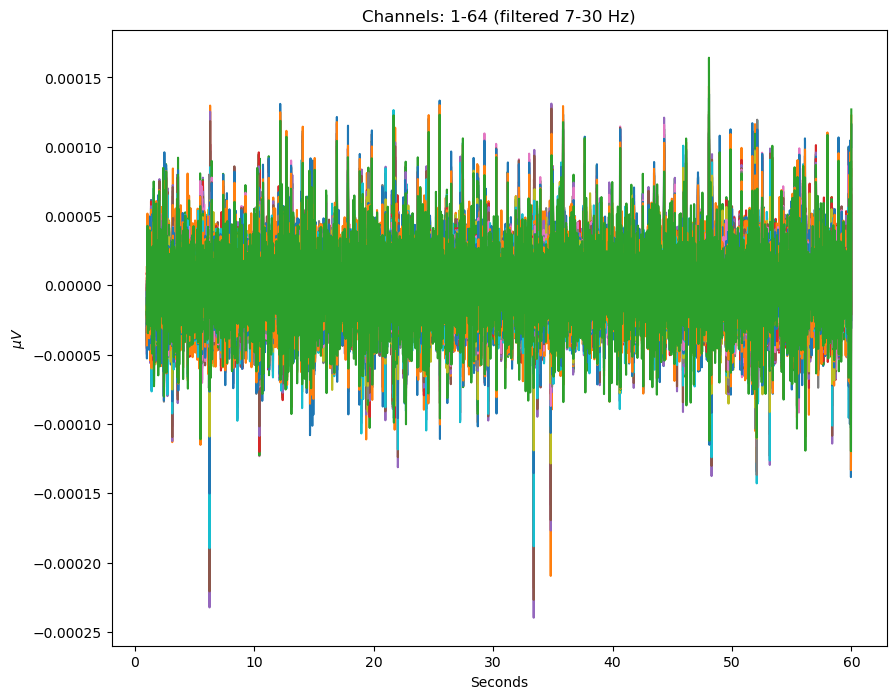

In [45]:
# Quick visualization of raw signal (first 60s)
raw_copy = raw_obj.copy().filter(7., 30., fir_design='firwin', skip_by_annotation='edge', verbose=False)
sfreq = raw_copy.info['sfreq']
data, times = raw_copy[:-1, int(sfreq * 1):int(sfreq * 60)]

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(times, data.T)
ax.set_xlabel('Seconds')
ax.set_ylabel('$\mu V$')
ax.set_title('Channels: 1-64 (filtered 7-30 Hz)')
plt.show()


Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


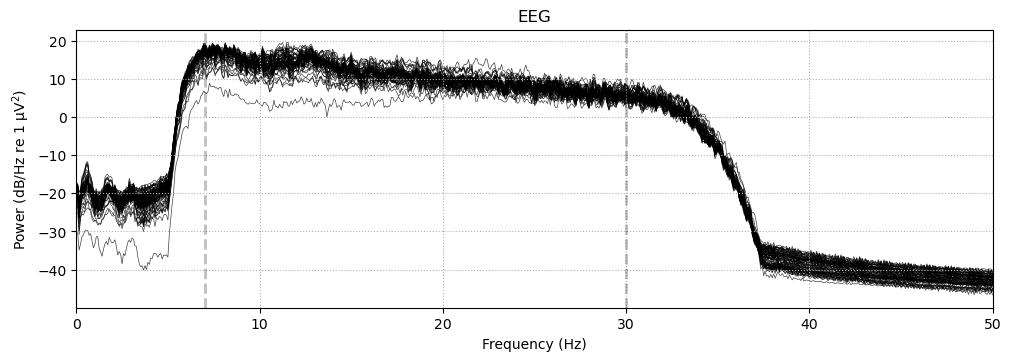

In [46]:
raw_copy.compute_psd(fmax=50).plot()
plt.show()


## 4. Global Subject Split — Fixed Once for All Experiments

**FIX:** We define a single, consistent train/val/test split of *subjects* 
that is reused across all sections. This ensures fair comparison between approaches.
Previously each section re-shuffled subjects independently.


In [47]:
all_subject_ids = sorted(raw_data.keys())
np.random.seed(SEED)
shuffled_subjects = np.array(all_subject_ids)
np.random.shuffle(shuffled_subjects)

n = len(shuffled_subjects)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

GLOBAL_TRAIN_SUBJECTS = set(shuffled_subjects[:n_train])
GLOBAL_VAL_SUBJECTS   = set(shuffled_subjects[n_train:n_train + n_val])
GLOBAL_TEST_SUBJECTS  = set(shuffled_subjects[n_train + n_val:])

print(f"Global split: {len(GLOBAL_TRAIN_SUBJECTS)} train / "
      f"{len(GLOBAL_VAL_SUBJECTS)} val / {len(GLOBAL_TEST_SUBJECTS)} test subjects")
print(f"Train subjects sample: {sorted(GLOBAL_TRAIN_SUBJECTS)[:5]}...")
print(f"Test subjects sample:  {sorted(GLOBAL_TEST_SUBJECTS)[:5]}...")

# Verify no overlap
assert len(GLOBAL_TRAIN_SUBJECTS & GLOBAL_VAL_SUBJECTS) == 0
assert len(GLOBAL_TRAIN_SUBJECTS & GLOBAL_TEST_SUBJECTS) == 0
assert len(GLOBAL_VAL_SUBJECTS & GLOBAL_TEST_SUBJECTS) == 0
print("✅ No subject overlap between splits")


Global split: 74 train / 15 val / 17 test subjects
Train subjects sample: [np.str_('001'), np.str_('004'), np.str_('005'), np.str_('006'), np.str_('007')]...
Test subjects sample:  [np.str_('002'), np.str_('003'), np.str_('015'), np.str_('021'), np.str_('022')]...
✅ No subject overlap between splits


## 5. Preprocessing & Epoching — Parameterized

Reusable function for all experiments. Per-subject z-score normalization 
is applied per channel across all epochs of that subject.


In [48]:
MOTOR_CHANNELS = [
    'Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.',
    'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..',
    'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.',
]


def epoch_all_subjects(raw_data, event_id, low_freq=7., high_freq=30.,
                       tmin=0.0, tmax=4.0, baseline=None,
                       channels=None, balance=True):
    """
    Epoch all subjects with given preprocessing parameters.
    
    Parameters
    ----------
    raw_data : dict of mne.Raw
    event_id : dict, e.g. {'rest': 1, 'left_hand': 2, 'right_hand': 3}
    channels : list or None. If None, use all 64 channels.
    balance : bool. If True, downsample to smallest class.
    
    Returns
    -------
    X_all, y_all, subjects_all : numpy arrays
    """
    all_X, all_y, all_subjects = [], [], []
    skipped = []
    n_classes = len(event_id)
    
    # Determine label remapping: make labels 0-indexed
    label_values = sorted(event_id.values())
    label_offset = min(label_values)

    for subject in raw_data:
        try:
            raw = raw_data[subject].copy()
            if channels is not None:
                raw.pick(channels)
            raw.filter(low_freq, high_freq, fir_design='firwin',
                       skip_by_annotation='edge', verbose=False)

            events, _ = mne.events_from_annotations(raw, event_id='auto', verbose=False)

            epochs = mne.Epochs(raw, events, event_id,
                                tmin=tmin, tmax=tmax,
                                baseline=baseline,
                                preload=True, verbose=False)

            X = epochs.get_data().astype(np.float32)
            y = epochs.events[:, -1] - label_offset  # 0-indexed labels

            # Per-subject z-score normalization per channel
            for ch in range(X.shape[1]):
                mean = X[:, ch, :].mean()
                std  = X[:, ch, :].std()
                if std > 0:
                    X[:, ch, :] = (X[:, ch, :] - mean) / std

            all_X.append(X)
            all_y.append(y)
            all_subjects.append(np.full(len(y), int(subject)))

        except Exception as e:
            skipped.append(subject)

    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    subjects_all = np.concatenate(all_subjects, axis=0)

    if balance:
        min_count = min(np.bincount(y_all))
        balanced_idx = []
        for cls in range(n_classes):
            cls_idx = np.where(y_all == cls)[0]
            chosen = np.random.choice(cls_idx, size=min_count, replace=False)
            balanced_idx.append(chosen)
        balanced_idx = np.concatenate(balanced_idx)
        np.random.shuffle(balanced_idx)
        X_all = X_all[balanced_idx]
        y_all = y_all[balanced_idx]
        subjects_all = subjects_all[balanced_idx]

    if skipped:
        print(f"Skipped {len(skipped)} subjects: {skipped[:5]}...")

    return X_all, y_all, subjects_all


def apply_global_split(X_all, y_all, subjects_all):
    """Apply the global train/val/test subject split."""
    train_mask = np.isin(subjects_all, [int(s) for s in GLOBAL_TRAIN_SUBJECTS])
    val_mask   = np.isin(subjects_all, [int(s) for s in GLOBAL_VAL_SUBJECTS])
    test_mask  = np.isin(subjects_all, [int(s) for s in GLOBAL_TEST_SUBJECTS])
    
    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
    X_test,  y_test  = X_all[test_mask],  y_all[test_mask]
    subjects_train   = subjects_all[train_mask]
    subjects_val     = subjects_all[val_mask]
    subjects_test    = subjects_all[test_mask]
    
    # CV data = train + val (test stays untouched)
    cv_mask = train_mask | val_mask
    X_cv, y_cv, subjects_cv = X_all[cv_mask], y_all[cv_mask], subjects_all[cv_mask]
    
    print(f"Train: {len(X_train)} epochs from {len(np.unique(subjects_train))} subjects")
    print(f"Val:   {len(X_val)} epochs from {len(np.unique(subjects_val))} subjects")
    print(f"Test:  {len(X_test)} epochs from {len(np.unique(subjects_test))} subjects")
    
    return {
        'X_train': X_train, 'y_train': y_train, 'subjects_train': subjects_train,
        'X_val': X_val, 'y_val': y_val, 'subjects_val': subjects_val,
        'X_test': X_test, 'y_test': y_test, 'subjects_test': subjects_test,
        'X_cv': X_cv, 'y_cv': y_cv, 'subjects_cv': subjects_cv,
        'train_mask': train_mask, 'val_mask': val_mask, 'test_mask': test_mask,
    }


## 6. Dataset & DataLoaders

**FIX:** Augmentation now correctly handles torch tensors and avoids 
wrap-around artifacts from `np.roll`.


In [49]:
class EEGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.augment:
            # Gaussian noise (on tensor)
            x = x + torch.randn_like(x) * 0.1
            # Time shift: zero-pad instead of wrap-around
            shift = torch.randint(-20, 21, (1,)).item()
            if shift > 0:
                x = torch.cat([torch.zeros_like(x[:, :shift]), x[:, :-shift]], dim=-1)
            elif shift < 0:
                x = torch.cat([x[:, -shift:], torch.zeros_like(x[:, :(-shift)])], dim=-1)
        return x, y


def make_loaders(split, batch_size=64, augment_train=False):
    train_ds = EEGDataset(split['X_train'], split['y_train'], augment=augment_train)
    val_ds   = EEGDataset(split['X_val'],   split['y_val'])
    test_ds  = EEGDataset(split['X_test'],  split['y_test'])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


## 7. EEGNet Model

In [50]:
class EEGNet(nn.Module):
    def __init__(self, chans=64, classes=3, time_points=641,
                 temp_kernel=80, f1=8, f2=16, d=2,
                 pk1=4, pk2=8, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        linear_size = (time_points // (pk1 * pk2)) * f2

        # Block 1: Temporal filtering
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, temp_kernel), padding='same', bias=False),
            nn.BatchNorm2d(f1),
        )

        # Block 2: Spatial filtering (depthwise)
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1)),
            nn.Dropout(dropout_rate),
        )

        # Block 3: Separable conv
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, d * f1, (1, 16), groups=d * f1, padding='same', bias=False),
            nn.Conv2d(d * f1, f2, 1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2)),
            nn.Dropout(dropout_rate),
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(linear_size, classes)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x


## 8. Training & Evaluation Functions

**FIX:** `train()` now uses a proper validation set for early stopping 
and only evaluates on test set once at the end — no information leaks 
from test set into model selection.


In [51]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_acc, n_batches = 0, 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        total_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_acc += (y_pred.argmax(dim=1) == y).sum().item() / len(y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches


def eval_step(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, total_acc, n_batches = 0, 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)
            total_loss += loss.item()
            total_acc += (logits.argmax(dim=1) == y).sum().item() / len(y)
            n_batches += 1
    return total_loss / n_batches, total_acc / n_batches


def train_model(model, train_loader, val_loader, test_loader,
                optimizer, loss_fn, device, epochs=50,
                scheduler=None, verbose=True):
    """
    Train with early stopping on VAL set, final evaluation on TEST set.
    Test set is never used for model selection.
    """
    results = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }

    best_val_acc = 0.0
    best_model_state = None

    iterator = tqdm(range(epochs)) if verbose else range(epochs)
    for epoch in iterator:
        train_loss, train_acc = train_step(model, train_loader, loss_fn, optimizer, device)
        if scheduler is not None:
            scheduler.step()
        val_loss, val_acc = eval_step(model, val_loader, loss_fn, device)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch: {epoch+1:3d} | "
                  f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
                  f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    # Restore best model (selected on val, NOT test)
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Final test evaluation (single pass, no selection)
    test_loss, test_acc = eval_step(model, test_loader, loss_fn, device)
    results["test_loss"] = test_loss
    results["test_acc"] = test_acc

    if verbose:
        print(f"\n{'='*50}")
        print(f"Best val_acc: {best_val_acc:.4f}")
        print(f"Final test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

    return results, best_val_acc


## 9. Subject-based K-Fold Cross-Validation

**FIX:** Now includes cosine annealing scheduler (consistent with single-run training).


In [52]:
def cross_validate_subjects(X, y, subjects, n_splits=5, epochs=50,
                            lr=0.001, batch_size=64, dropout_rate=0.5,
                            f1=8, f2=16, d=2, temp_kernel=80,
                            chans=64, classes=3, verbose=True,
                            cv_label=None):
    """
    Subject-based K-Fold CV. No subject leaks between folds.
    Stores per-fold details in CV_DETAILS if cv_label is provided.
    """
    time_points = X.shape[2]
    gkf = GroupKFold(n_splits=n_splits)
    fold_results = []
    fold_details = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=subjects)):
        if verbose:
            print(f"\nFold {fold+1}/{n_splits}: "
                  f"train={len(train_idx)}, val={len(val_idx)}")

        X_tr, y_tr = X[train_idx], y[train_idx]
        X_vl, y_vl = X[val_idx], y[val_idx]

        train_dl = DataLoader(EEGDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_dl   = DataLoader(EEGDataset(X_vl, y_vl), batch_size=batch_size, shuffle=False)

        model = EEGNet(chans=chans, classes=classes, time_points=time_points,
                       f1=f1, f2=f2, d=d, dropout_rate=dropout_rate,
                       temp_kernel=temp_kernel).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        fold_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        loss_fn = nn.CrossEntropyLoss(
            weight=torch.tensor(fold_weights, dtype=torch.float32).to(device)
        )

        best_val_acc = 0.0
        train_curve = []
        for epoch in range(epochs):
            tr_loss, tr_acc = train_step(model, train_dl, loss_fn, optimizer, device)
            scheduler.step()
            vl_loss, val_acc = eval_step(model, val_dl, loss_fn, device)
            train_curve.append({
                'epoch': epoch, 'train_loss': tr_loss, 'train_acc': tr_acc,
                'val_loss': vl_loss, 'val_acc': val_acc
            })
            if val_acc > best_val_acc:
                best_val_acc = val_acc

        if verbose:
            print(f"Fold {fold+1} best val_acc: {best_val_acc:.4f}")
        fold_results.append(best_val_acc)
        
        fold_details.append({
            'fold': fold + 1,
            'n_train': len(train_idx),
            'n_val': len(val_idx),
            'train_subjects': sorted(np.unique(subjects[train_idx]).tolist()),
            'val_subjects': sorted(np.unique(subjects[val_idx]).tolist()),
            'best_val_acc': best_val_acc,
            'train_curve': train_curve,
        })

    mean_acc = np.mean(fold_results)
    std_acc = np.std(fold_results)
    if verbose:
        print(f"\nCV: {mean_acc:.4f} ± {std_acc:.4f}")
    
    # Store in global CV details
    if cv_label:
        CV_DETAILS[cv_label] = {
            'n_splits': n_splits,
            'fold_accuracies': fold_results,
            'mean_accuracy': mean_acc,
            'std_accuracy': std_acc,
            'fold_details': fold_details,
            'hyperparams': {
                'lr': lr, 'f1': f1, 'f2': f2, 'd': d,
                'dropout_rate': dropout_rate, 'epochs': epochs,
                'chans': chans, 'classes': classes,
            },
        }

    return fold_results, mean_acc, std_acc


## 10. MultiClassCSP — Pairwise CSP for 3-class problems

**FIX:** Removed the broken double-CSP pipeline. This is the correct 
pairwise approach: one binary CSP per class pair, features concatenated.


In [53]:
class MultiClassCSP(BaseEstimator, TransformerMixin):
    """
    Pairwise CSP for multiclass problems.
    Trains a separate binary CSP for each pair of classes,
    then concatenates all features into one vector.
    """
    def __init__(self, n_components=4, reg='ledoit_wolf'):
        self.n_components = n_components
        self.reg = reg

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pairs_ = list(itertools.combinations(self.classes_, 2))
        self.csps_ = []
        for (c1, c2) in self.pairs_:
            csp = CSP(n_components=self.n_components, reg=self.reg,
                      log=True, norm_trace=False)
            mask = (y == c1) | (y == c2)
            csp.fit(X[mask], y[mask])
            self.csps_.append(csp)
        return self

    def transform(self, X):
        features = [csp.transform(X) for csp in self.csps_]
        return np.concatenate(features, axis=1)


## 11. Evaluation Helpers

In [54]:
def get_full_metrics(y_true, y_pred, target_names):
    """Compute comprehensive metrics from predictions."""
    from sklearn.metrics import (accuracy_score, classification_report, 
                                  confusion_matrix, cohen_kappa_score,
                                  balanced_accuracy_score, f1_score,
                                  precision_score, recall_score)
    
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    
    precision = precision_score(y_true, y_pred, average=None)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average=None)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    return {
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'cohen_kappa': kappa,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': {name: float(p) for name, p in zip(target_names, precision)},
        'recall_per_class': {name: float(r) for name, r in zip(target_names, recall)},
        'f1_per_class': {name: float(f) for name, f in zip(target_names, f1)},
        'confusion_matrix': cm,
        'classification_report': report,
    }


def evaluate_and_plot(model_or_pipeline, test_loader_or_X, y_test,
                      target_names, title, device='cpu', is_nn=True):
    """Evaluate model, print report, plot confusion matrix, return full metrics."""
    if is_nn:
        model_or_pipeline.eval()
        all_preds, all_labels = [], []
        with torch.inference_mode():
            for X_batch, y_batch in test_loader_or_X:
                preds = model_or_pipeline(X_batch.to(device)).argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(y_batch.numpy())
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
    else:
        all_preds = model_or_pipeline.predict(test_loader_or_X)
        all_labels = np.array(y_test)
    
    metrics = get_full_metrics(all_labels, all_preds, target_names)
    
    print(f"\nTest Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Cohen's Kappa:     {metrics['cohen_kappa']:.4f}")
    print(f"F1 (macro):        {metrics['f1_macro']:.4f}")
    print(f"F1 (weighted):     {metrics['f1_weighted']:.4f}")
    print()
    print(classification_report(all_labels, all_preds, target_names=target_names))
    
    cm = metrics['confusion_matrix']
    plt.figure(figsize=(max(6, len(target_names)*2), max(5, len(target_names)*1.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.show()
    
    # Normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(max(6, len(target_names)*2), max(5, len(target_names)*1.5)))
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix — {title}')
    plt.tight_layout()
    plt.show()
    
    return metrics, all_preds, all_labels


def plot_training_curves(results, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(results['train_loss'], label='Train')
    axes[0].plot(results['val_loss'], label='Val')
    axes[0].set_title(f'Loss {title}')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(results['train_acc'], label='Train')
    axes[1].plot(results['val_acc'], label='Val')
    axes[1].set_title(f'Accuracy {title}')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


---
# PART A: 3-Class Classification (rest / left / right) — 64 Channels

## 12. Epoching & Split


In [55]:
event_id_3class = {'rest': 1, 'left_hand': 2, 'right_hand': 3}

X_all_64, y_all_64, subjects_all_64 = epoch_all_subjects(
    raw_data, event_id_3class,
    low_freq=7., high_freq=30., tmin=0.0, tmax=4.0,
    channels=None,  # all 64 channels
)

print(f"Shape: {X_all_64.shape}")
print(f"Class distribution: {np.bincount(y_all_64)}")
print(f"Unique subjects: {len(np.unique(subjects_all_64))}")

split_64 = apply_global_split(X_all_64, y_all_64, subjects_all_64)
print(f"Train class dist: {np.bincount(split_64['y_train'])}")
print(f"Test class dist:  {np.bincount(split_64['y_test'])}")


Shape: (7056, 64, 641)
Class distribution: [2352 2352 2352]
Unique subjects: 106
Train: 4924 epochs from 74 subjects
Val:   1012 epochs from 15 subjects
Test:  1120 epochs from 17 subjects
Train class dist: [1636 1642 1646]
Test class dist:  [365 378 377]


## 13. Single Run — EEGNet (64 channels, 3 classes)

In [56]:
train_loader, val_loader, test_loader = make_loaders(split_64)

eeg_net_64 = EEGNet(chans=64, classes=3).to(device)

class_weights = compute_class_weight('balanced', classes=np.unique(split_64['y_train']),
                                     y=split_64['y_train'])
loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)
print(f"Class weights: {class_weights}")

optimizer = torch.optim.Adam(eeg_net_64.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

results_64, best_val_64 = train_model(
    model=eeg_net_64,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    scheduler=scheduler,
    epochs=50
)


Class weights: [1.00325998 0.99959399 0.99716484]


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch:   1 | train_loss: 1.1075 | train_acc: 0.3471 | val_loss: 1.0981 | val_acc: 0.3441
Epoch:   2 | train_loss: 1.0946 | train_acc: 0.3729 | val_loss: 1.0966 | val_acc: 0.3764
Epoch:   3 | train_loss: 1.0760 | train_acc: 0.4079 | val_loss: 1.1069 | val_acc: 0.3725
Epoch:   4 | train_loss: 1.0602 | train_acc: 0.4193 | val_loss: 1.1051 | val_acc: 0.3913
Epoch:   5 | train_loss: 1.0399 | train_acc: 0.4494 | val_loss: 1.1023 | val_acc: 0.4027
Epoch:   6 | train_loss: 1.0245 | train_acc: 0.4674 | val_loss: 1.0829 | val_acc: 0.4283
Epoch:   7 | train_loss: 1.0041 | train_acc: 0.4845 | val_loss: 1.0537 | val_acc: 0.4734
Epoch:   8 | train_loss: 0.9846 | train_acc: 0.5074 | val_loss: 1.0485 | val_acc: 0.4720
Epoch:   9 | train_loss: 0.9721 | train_acc: 0.5187 | val_loss: 1.0240 | val_acc: 0.4885
Epoch:  10 | train_loss: 0.9529 | train_acc: 0.5327 | val_loss: 0.9998 | val_acc: 0.4975
Epoch:  11 | train_loss: 0.9469 | train_acc: 0.5345 | val_loss: 1.0150 | val_acc: 0.5029
Epoch:  12 | train_lo

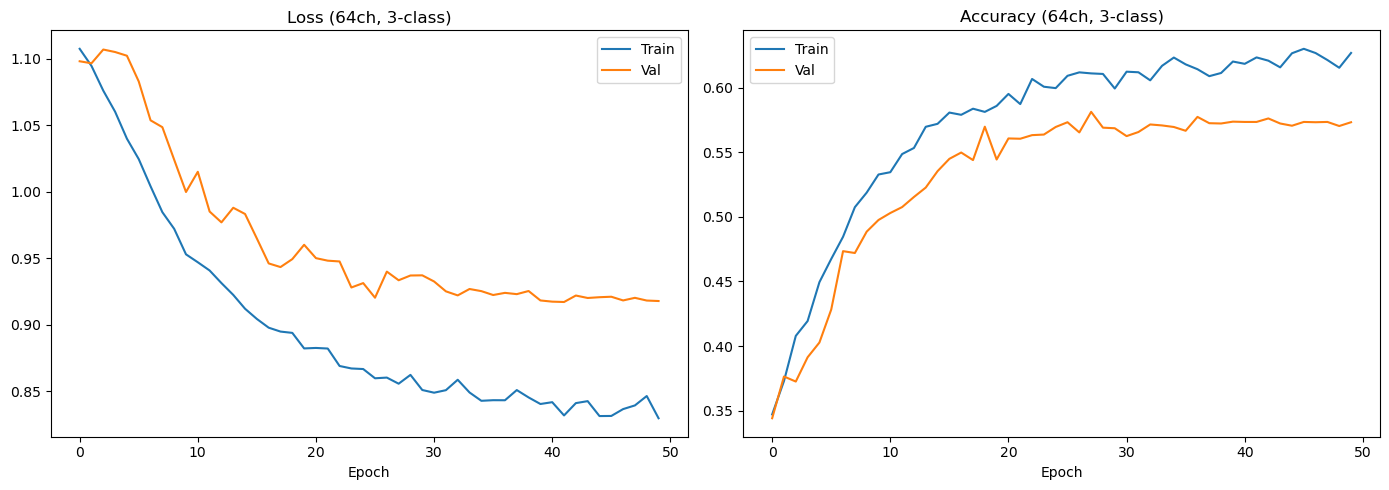

In [57]:
plot_training_curves(results_64, "(64ch, 3-class)")



Test Accuracy:    0.6009
Balanced Accuracy: 0.6009
Cohen's Kappa:     0.4012
F1 (macro):        0.6006
F1 (weighted):     0.6005

              precision    recall  f1-score   support

        rest       0.63      0.60      0.61       365
   left_hand       0.68      0.52      0.59       378
  right_hand       0.53      0.69      0.60       377

    accuracy                           0.60      1120
   macro avg       0.62      0.60      0.60      1120
weighted avg       0.62      0.60      0.60      1120



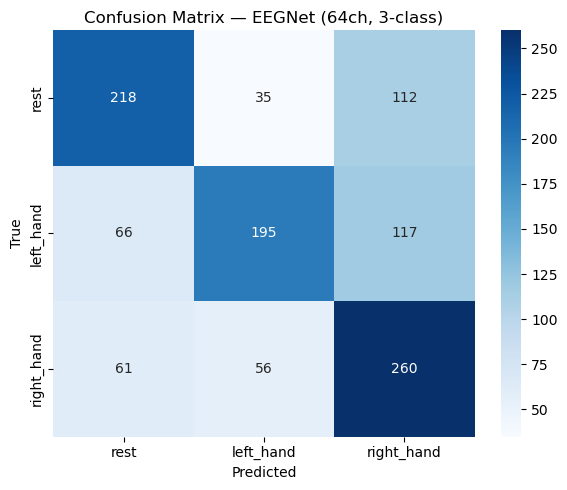

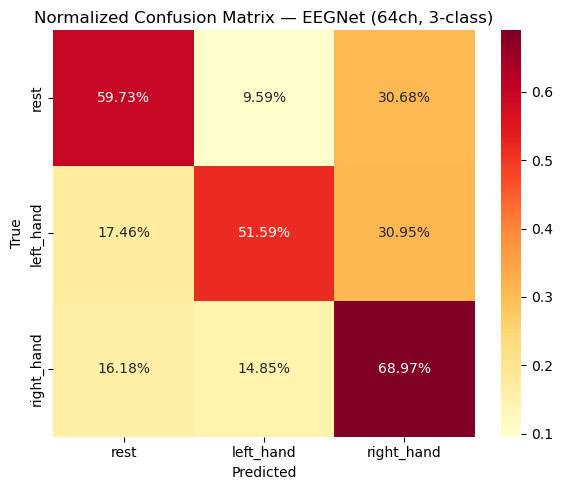

  💾 Saved: models/eegnet_64ch_3class_single_run.pth
  📊 Registered: 3class_64ch / EEGNet / EEGNet_single_run → test_acc=0.6009


{'timestamp': '2026-03-16T19:06:31.807104',
 'experiment': '3class_64ch',
 'approach': 'EEGNet',
 'model_name': 'EEGNet_single_run',
 'test_accuracy': 0.6008928571428571,
 'test_loss': 0.8482943309677972,
 'cv_mean_accuracy': None,
 'cv_std_accuracy': None,
 'cv_fold_accuracies': None,
 'precision_per_class': {'rest': 0.6318840579710145,
  'left_hand': 0.6818181818181818,
  'right_hand': 0.5316973415132924},
 'recall_per_class': {'rest': 0.5972602739726027,
  'left_hand': 0.5158730158730159,
  'right_hand': 0.6896551724137931},
 'f1_per_class': {'rest': 0.6140845070422535,
  'left_hand': 0.5873493975903614,
  'right_hand': 0.6004618937644342},
 'confusion_matrix': [[218, 35, 112], [66, 195, 117], [61, 56, 260]],
 'classification_report': {'rest': {'precision': 0.6318840579710145,
   'recall': 0.5972602739726027,
   'f1-score': 0.6140845070422535,
   'support': 365.0},
  'left_hand': {'precision': 0.6818181818181818,
   'recall': 0.5158730158730159,
   'f1-score': 0.5873493975903614,
  

In [58]:
metrics_64_eegnet, _, _ = evaluate_and_plot(
    eeg_net_64, test_loader, split_64['y_test'],
    ['rest', 'left_hand', 'right_hand'],
    'EEGNet (64ch, 3-class)', device
)
acc_64_eegnet = metrics_64_eegnet['accuracy']

save_nn_model(eeg_net_64, 'eegnet_64ch_3class_single_run', meta={
    'chans': 64, 'classes': 3, 'time_points': 641,
    'test_accuracy': acc_64_eegnet,
})

register_result(
    experiment='3class_64ch', approach='EEGNet', model_name='EEGNet_single_run',
    test_acc=metrics_64_eegnet['accuracy'],
    test_loss=results_64.get('test_loss'),
    precision=metrics_64_eegnet['precision_per_class'],
    recall=metrics_64_eegnet['recall_per_class'],
    f1=metrics_64_eegnet['f1_per_class'],
    confusion_mat=metrics_64_eegnet['confusion_matrix'],
    class_report_dict=metrics_64_eegnet['classification_report'],
    train_history={'train_loss': results_64['train_loss'], 'train_acc': results_64['train_acc'],
                   'val_loss': results_64['val_loss'], 'val_acc': results_64['val_acc']},
    n_train=len(split_64['y_train']), n_test=len(split_64['y_test']),
    extra={'balanced_accuracy': metrics_64_eegnet['balanced_accuracy'],
           'cohen_kappa': metrics_64_eegnet['cohen_kappa'],
           'f1_macro': metrics_64_eegnet['f1_macro'],
           'f1_weighted': metrics_64_eegnet['f1_weighted']},
)


## 14. Subject-based K-Fold CV (64 channels)

In [21]:
fold_results_64, mean_acc_64, std_acc_64 = cross_validate_subjects(
    split_64['X_cv'], split_64['y_cv'], split_64['subjects_cv'],
    n_splits=5, epochs=50, lr=0.001, chans=64, classes=3,
    cv_label='EEGNet_64ch_3class_5fold'
)



Fold 1/5: train=4735, val=1201
Fold 1 best val_acc: 0.6076

Fold 2/5: train=4735, val=1201


KeyboardInterrupt: 

## 15. EEGNet Hyperparameter Grid Search (64 channels)

In [59]:
param_grid = {
    'lr':           [0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total hyperparameter combinations: {len(combos)}")

grid_results_64 = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']
    print(f"\nCombo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        split_64['X_cv'], split_64['y_cv'], split_64['subjects_cv'],
        n_splits=3, epochs=30,
        lr=params['lr'], dropout_rate=params['dropout_rate'],
        f1=params['f1'], f2=f2, d=params['d'],
        chans=64, classes=3, verbose=False
    )
    grid_results_64.append({**params, 'f2': f2, 'mean_acc': mean_acc, 'std_acc': std_acc})
    print(f"  → {mean_acc:.4f} ± {std_acc:.4f}")

grid_df_64 = pd.DataFrame(grid_results_64).sort_values('mean_acc', ascending=False)
print("\nGrid Search Results (64ch):")
print(grid_df_64.to_string(index=False))


Total hyperparameter combinations: 16

Combo 1/16: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 8, 'd': 2}, f2=16
  → 0.6138 ± 0.0247

Combo 2/16: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 8, 'd': 4}, f2=32
  → 0.6356 ± 0.0251

Combo 3/16: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 16, 'd': 2}, f2=32
  → 0.6609 ± 0.0207

Combo 4/16: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 16, 'd': 4}, f2=64
  → 0.6643 ± 0.0114

Combo 5/16: {'lr': 0.001, 'dropout_rate': 0.5, 'f1': 8, 'd': 2}, f2=16
  → 0.5569 ± 0.0353

Combo 6/16: {'lr': 0.001, 'dropout_rate': 0.5, 'f1': 8, 'd': 4}, f2=32
  → 0.5933 ± 0.0285

Combo 7/16: {'lr': 0.001, 'dropout_rate': 0.5, 'f1': 16, 'd': 2}, f2=32
  → 0.5950 ± 0.0182

Combo 8/16: {'lr': 0.001, 'dropout_rate': 0.5, 'f1': 16, 'd': 4}, f2=64
  → 0.6288 ± 0.0310

Combo 9/16: {'lr': 0.0005, 'dropout_rate': 0.25, 'f1': 8, 'd': 2}, f2=16
  → 0.5651 ± 0.0237

Combo 10/16: {'lr': 0.0005, 'dropout_rate': 0.25, 'f1': 8, 'd': 4}, f2=32
  → 0.5993 ± 0.0242

Combo 11/16: {'lr': 0.0005, 

## 16. Final Model — Best Hyperparameters (64 channels)

**FIX:** Early stopping uses validation set, not test set.
We train on train set, select best epoch on val set, then evaluate once on test.


In [ ]:
best_params_64 = grid_df_64.iloc[0].to_dict()
print(f"Best hyperparameters: {best_params_64}")

final_model_64 = EEGNet(
    chans=64, classes=3,
    f1=int(best_params_64['f1']),
    f2=int(best_params_64['f2']),
    d=int(best_params_64['d']),
    dropout_rate=best_params_64['dropout_rate'],
).to(device)

# Train on train set, early stop on val set, evaluate on test set
train_loader, val_loader, test_loader = make_loaders(split_64)

optimizer = torch.optim.Adam(final_model_64.parameters(), lr=best_params_64['lr'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

final_weights = compute_class_weight('balanced',
    classes=np.unique(split_64['y_train']), y=split_64['y_train'])
loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(final_weights, dtype=torch.float32).to(device)
)

results_final_64, _ = train_model(
    model=final_model_64,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scheduler=scheduler,
    device=device,
    epochs=50
)

metrics_64_final, _, _ = evaluate_and_plot(
    final_model_64, test_loader, split_64['y_test'],
    ['rest', 'left_hand', 'right_hand'],
    'Final EEGNet (64ch)', device
)


acc_64_final = metrics_64_final['accuracy']

save_nn_model(final_model_64, 'eegnet_64ch_3class_best_grid', meta={
    'chans': 64, 'classes': 3, 'best_params': best_params_64,
    'test_accuracy': acc_64_final,
})

register_result(
    experiment='3class_64ch', approach='EEGNet', model_name='EEGNet_best_grid',
    test_acc=metrics_64_final['accuracy'],
    test_loss=results_final_64.get('test_loss'),
    precision=metrics_64_final['precision_per_class'],
    recall=metrics_64_final['recall_per_class'],
    f1=metrics_64_final['f1_per_class'],
    confusion_mat=metrics_64_final['confusion_matrix'],
    class_report_dict=metrics_64_final['classification_report'],
    best_params=best_params_64,
    n_train=len(split_64['y_train']), n_test=len(split_64['y_test']),
    extra={'balanced_accuracy': metrics_64_final['balanced_accuracy'],
           'cohen_kappa': metrics_64_final['cohen_kappa'],
           'f1_macro': metrics_64_final['f1_macro'],
           'f1_weighted': metrics_64_final['f1_weighted']},
)


## 17. CSP + LDA One-vs-Rest (64 channels)

**FIX:** Uses a single CSP step (the original had two CSPs stacked, which is broken).


In [60]:
csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

pipe_ovr = Pipeline([
    ('csp', csp),
    ('classifier', OneVsRestClassifier(lda))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipe_ovr,
    split_64['X_cv'], split_64['y_cv'],
    cv=gkf, groups=split_64['subjects_cv'], scoring='accuracy')
print(f"CSP+LDA OvR (64ch): {scores.mean():.4f} ± {scores.std():.4f}")


Computing rank from data with rank=None
    Using tolerance 1.5e+02 (2.2e-16 eps * 64 dim * 1e+16  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.5e+02 (2.2e-16 eps * 64 dim * 1e+16  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 1.5e+02 (2.2e-16 eps * 64 dim * 1e+16  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed fr

## 18. CSP Pairwise + Classical ML Grid Search (64 channels)

In [61]:
def get_ml_models():
    return {
        'LDA': {
            'model': LinearDiscriminantAnalysis(),
            'params': [
                {'classifier__solver': ['svd'], 'classifier__shrinkage': [None],
                 'csp__n_components': [4, 6]},
                {'classifier__solver': ['lsqr'], 'classifier__shrinkage': [None, 'auto'],
                 'csp__n_components': [4, 6]},
            ]
        },
        'SVM': {
            'model': SVC(probability=True, random_state=42, class_weight='balanced'),
            'params': {
                'classifier__C': [0.1, 1.0, 10.0],
                'classifier__kernel': ['rbf', 'linear'],
                'classifier__gamma': ['scale', 'auto'],
                'csp__n_components': [4, 6],
            }
        },
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
                'classifier__n_estimators': [100, 200],
                'classifier__max_depth': [5, 10, None],
                'classifier__min_samples_leaf': [1, 5],
                'csp__n_components': [4, 6],
            }
        },
        'KNN': {
            'model': KNeighborsClassifier(),
            'params': {
                'classifier__n_neighbors': [3, 5, 7, 11],
                'classifier__weights': ['uniform', 'distance'],
                'classifier__metric': ['euclidean', 'manhattan'],
                'csp__n_components': [4, 6],
            }
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {
                'classifier__n_estimators': [100, 200],
                'classifier__learning_rate': [0.01, 0.1],
                'classifier__max_depth': [3, 5],
                'csp__n_components': [4, 6],
            }
        },
        'LogisticRegression': {
            'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
            'params': {
                'classifier__C': [0.01, 0.1, 1.0, 10.0],
                'classifier__penalty': ['l1', 'l2'],
                'classifier__solver': ['saga'],
                'csp__n_components': [4, 6],
            }
        },
        'MLP': {
            'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
            'params': {
                'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32)],
                'classifier__alpha': [0.0001, 0.001],
                'classifier__learning_rate_init': [0.001, 0.01],
                'csp__n_components': [4, 6],
            }
        },
    }


def run_ml_grid_search(X_cv, y_cv, subjects_cv, X_test, y_test,
                       models, csp_class, target_names, n_splits=5,
                       experiment_label=''):
    """Run grid search for all ML models. Saves best model + registers all metrics."""
    gkf = GroupKFold(n_splits=n_splits)
    all_results = []

    for name, config in models.items():
        print(f"\n{'#'*60}")
        print(f"  {name}")
        print(f"{'#'*60}")

        pipe = Pipeline([
            ('csp', csp_class),
            ('scaler', StandardScaler()),
            ('classifier', config['model']),
        ])

        grid = GridSearchCV(
            pipe, param_grid=config['params'],
            cv=gkf, scoring='accuracy', n_jobs=-1, verbose=0, error_score='raise',
        )

        start = time.time()
        grid.fit(X_cv, y_cv, groups=subjects_cv)
        elapsed = time.time() - start

        print(f"Best params: {grid.best_params_}")
        print(f"Best CV accuracy: {grid.best_score_:.4f}")
        print(f"Time: {elapsed:.1f}s")

        all_results.append({
            'model': name,
            'best_cv_acc': grid.best_score_,
            'best_cv_std': grid.cv_results_['std_test_score'][grid.best_index_],
            'best_params': grid.best_params_,
            'time_s': elapsed,
            'grid_obj': grid,
        })

    # Summary table
    results_df = pd.DataFrame([
        {'Model': r['model'], 'CV Accuracy': r['best_cv_acc'], 
         'CV Std': r['best_cv_std'], 'Time (s)': r['time_s']}
        for r in all_results
    ]).sort_values('CV Accuracy', ascending=False)
    print("\n" + "="*60)
    print(results_df.to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
    bars = ax.barh(results_df['Model'], results_df['CV Accuracy'], color=colors)
    ax.set_xlabel('CV Accuracy')
    ax.set_title(f'ML Model Comparison — {experiment_label}')
    ax.set_xlim(0.3, max(results_df['CV Accuracy']) + 0.05)
    for bar, acc in zip(bars, results_df['CV Accuracy']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{acc:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

    # Best model evaluation on test + save
    best_result = max(all_results, key=lambda x: x['best_cv_acc'])
    best_ml = best_result['grid_obj'].best_estimator_
    y_pred = best_ml.predict(X_test)
    
    metrics = get_full_metrics(y_test, y_pred, target_names)
    
    print(f"\nBest ML: {best_result['model']}")
    print(f"Test Accuracy:     {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Cohen's Kappa:     {metrics['cohen_kappa']:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Save best ML pipeline
    save_name = f"best_ml_{experiment_label}".replace(' ', '_').lower()
    save_sklearn_model(best_ml, save_name, meta={
        'experiment': experiment_label,
        'model': best_result['model'],
        'best_params': {k: str(v) for k, v in best_result['best_params'].items()},
        'cv_accuracy': best_result['best_cv_acc'],
        'test_accuracy': metrics['accuracy'],
    })

    # Register all ML results
    for r in all_results:
        ml_pipe = r['grid_obj'].best_estimator_
        ml_pred = ml_pipe.predict(X_test)
        ml_met = get_full_metrics(y_test, ml_pred, target_names)
        
        register_result(
            experiment=experiment_label,
            approach='CSP+ML',
            model_name=f"CSP+{r['model']}",
            test_acc=ml_met['accuracy'],
            cv_mean=r['best_cv_acc'],
            cv_std=r['best_cv_std'],
            precision=ml_met['precision_per_class'],
            recall=ml_met['recall_per_class'],
            f1=ml_met['f1_per_class'],
            confusion_mat=ml_met['confusion_matrix'],
            class_report_dict=ml_met['classification_report'],
            best_params={k: str(v) for k, v in r['best_params'].items()},
            n_train=len(y_cv),
            n_test=len(y_test),
            extra={
                'balanced_accuracy': ml_met['balanced_accuracy'],
                'cohen_kappa': ml_met['cohen_kappa'],
                'f1_macro': ml_met['f1_macro'],
                'f1_weighted': ml_met['f1_weighted'],
                'training_time_s': r['time_s'],
            }
        )

    return all_results, results_df, metrics['accuracy']


In [ ]:
# Run 3-class ML grid search (64 channels, pairwise CSP)
ml_results_64, ml_df_64, ml_test_acc_64 = run_ml_grid_search(
    split_64['X_cv'], split_64['y_cv'], split_64['subjects_cv'],
    split_64['X_test'], split_64['y_test'],
    models=get_ml_models(),
    csp_class=MultiClassCSP(n_components=4, reg='ledoit_wolf'),
    target_names=['rest', 'left_hand', 'right_hand'],
    experiment_label='3class_64ch',
)


---
# PART B: 3-Class Classification — 21 Motor Cortex Channels

## 19. Epoching & Split (21 channels)


In [62]:
X_all_21, y_all_21, subjects_all_21 = epoch_all_subjects(
    raw_data, event_id_3class,
    low_freq=7., high_freq=30., tmin=0.0, tmax=4.0,
    channels=MOTOR_CHANNELS,
)

print(f"Shape: {X_all_21.shape}")
print(f"Class distribution: {np.bincount(y_all_21)}")

split_21 = apply_global_split(X_all_21, y_all_21, subjects_all_21)


Shape: (7056, 21, 641)
Class distribution: [2352 2352 2352]
Train: 4933 epochs from 74 subjects
Val:   1004 epochs from 15 subjects
Test:  1119 epochs from 17 subjects


## 20. EEGNet Single Run (21 channels)

In [ ]:
train_loader_21, val_loader_21, test_loader_21 = make_loaders(split_21)

eeg_net_21 = EEGNet(chans=21, classes=3).to(device)

cw_21 = compute_class_weight('balanced', classes=np.unique(split_21['y_train']),
                              y=split_21['y_train'])
loss_fn_21 = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_21, dtype=torch.float32).to(device)
)

optimizer_21 = torch.optim.Adam(eeg_net_21.parameters(), lr=0.001)
scheduler_21 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_21, T_max=55)

results_21, _ = train_model(
    model=eeg_net_21,
    train_loader=train_loader_21,
    val_loader=val_loader_21,
    test_loader=test_loader_21,
    optimizer=optimizer_21,
    loss_fn=loss_fn_21,
    scheduler=scheduler_21,
    device=device,
    epochs=55
)

plot_training_curves(results_21, "(21ch, 3-class)")

metrics_21_eegnet, _, _ = evaluate_and_plot(
    eeg_net_21, test_loader_21, split_21['y_test'],
    ['rest', 'left_hand', 'right_hand'],
    'EEGNet (21ch, 3-class)', device
)


acc_21_eegnet = metrics_21_eegnet['accuracy']
save_nn_model(eeg_net_21, 'eegnet_21ch_3class_single_run')
register_result(
    experiment='3class_21ch', approach='EEGNet', model_name='EEGNet_single_run',
    test_acc=metrics_21_eegnet['accuracy'],
    precision=metrics_21_eegnet['precision_per_class'],
    recall=metrics_21_eegnet['recall_per_class'],
    f1=metrics_21_eegnet['f1_per_class'],
    confusion_mat=metrics_21_eegnet['confusion_matrix'],
    n_train=len(split_21['y_train']), n_test=len(split_21['y_test']),
    extra={'balanced_accuracy': metrics_21_eegnet['balanced_accuracy'],
           'cohen_kappa': metrics_21_eegnet['cohen_kappa'],
           'f1_macro': metrics_21_eegnet['f1_macro']},
)


## 21. CV + Grid Search (21 channels)

In [63]:
fold_results_21, mean_acc_21, std_acc_21 = cross_validate_subjects(
    split_21['X_cv'], split_21['y_cv'], split_21['subjects_cv'],
    n_splits=5, epochs=50, lr=0.001, chans=21, classes=3
,
    cv_label='EEGNet_21ch_3class_5fold'
)


Fold 1/5: train=4739, val=1198
Fold 1 best val_acc: 0.5340

Fold 2/5: train=4797, val=1140
Fold 2 best val_acc: 0.5329

Fold 3/5: train=4737, val=1200
Fold 3 best val_acc: 0.4918

Fold 4/5: train=4737, val=1200
Fold 4 best val_acc: 0.5674

Fold 5/5: train=4738, val=1199
Fold 5 best val_acc: 0.5569

CV: 0.5366 ± 0.0261


In [ ]:
param_grid = {
    'lr':           [0.005, 0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combos)}")

grid_results_21 = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']
    print(f"\nCombo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        split_21['X_cv'], split_21['y_cv'], split_21['subjects_cv'],
        n_splits=3, epochs=30,
        lr=params['lr'], dropout_rate=params['dropout_rate'],
        f1=params['f1'], f2=f2, d=params['d'],
        chans=21, classes=3, verbose=False
    )
    grid_results_21.append({**params, 'f2': f2, 'mean_acc': mean_acc, 'std_acc': std_acc})
    print(f"  → {mean_acc:.4f} ± {std_acc:.4f}")

grid_df_21 = pd.DataFrame(grid_results_21).sort_values('mean_acc', ascending=False)
print("\nGrid Search Results (21ch):")
print(grid_df_21.to_string(index=False))


## 22. Final EEGNet (21 channels)

In [ ]:
best_21 = grid_df_21.iloc[0].to_dict()
print(f"Best: {best_21}")

final_model_21 = EEGNet(
    chans=21, classes=3,
    f1=int(best_21['f1']), f2=int(best_21['f2']),
    d=int(best_21['d']), dropout_rate=best_21['dropout_rate'],
).to(device)

optimizer = torch.optim.Adam(final_model_21.parameters(), lr=best_21['lr'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(
        compute_class_weight('balanced', classes=np.unique(split_21['y_train']),
                             y=split_21['y_train']),
        dtype=torch.float32
    ).to(device)
)

results_final_21, _ = train_model(
    model=final_model_21,
    train_loader=train_loader_21,
    val_loader=val_loader_21,
    test_loader=test_loader_21,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scheduler=scheduler,
    device=device,
    epochs=50
)

metrics_21_final, _, _ = evaluate_and_plot(
    final_model_21, test_loader_21, split_21['y_test'],
    ['rest', 'left_hand', 'right_hand'],
    'Final EEGNet (21ch)', device
)


acc_21_final = metrics_21_final['accuracy']
save_nn_model(final_model_21, 'eegnet_21ch_3class_best_grid', meta={'best_params': best_21})
register_result(
    experiment='3class_21ch', approach='EEGNet', model_name='EEGNet_best_grid',
    test_acc=metrics_21_final['accuracy'],
    precision=metrics_21_final['precision_per_class'],
    recall=metrics_21_final['recall_per_class'],
    f1=metrics_21_final['f1_per_class'],
    confusion_mat=metrics_21_final['confusion_matrix'],
    best_params=best_21,
    n_train=len(split_21['y_train']), n_test=len(split_21['y_test']),
    extra={'balanced_accuracy': metrics_21_final['balanced_accuracy'],
           'cohen_kappa': metrics_21_final['cohen_kappa'],
           'f1_macro': metrics_21_final['f1_macro']},
)


## 23. CSP OvR (21 channels)

In [ ]:
csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

pipe_ovr_21 = Pipeline([
    ('csp', csp),
    ('classifier', OneVsRestClassifier(lda))
])

gkf = GroupKFold(n_splits=5)
scores_21 = cross_val_score(pipe_ovr_21,
    split_21['X_cv'], split_21['y_cv'],
    cv=gkf, groups=split_21['subjects_cv'], scoring='accuracy')
print(f"CSP+LDA OvR (21ch): {scores_21.mean():.4f} ± {scores_21.std():.4f}")


## 24. CSP Pairwise + ML Grid Search (21 channels)

In [ ]:
ml_results_21, ml_df_21, ml_test_acc_21 = run_ml_grid_search(
    split_21['X_cv'], split_21['y_cv'], split_21['subjects_cv'],
    split_21['X_test'], split_21['y_test'],
    models=get_ml_models(),
    csp_class=MultiClassCSP(n_components=4, reg='ledoit_wolf'),
    target_names=['rest', 'left_hand', 'right_hand'],
    experiment_label='3class_21ch',
)


---
# PART C: Two-Stage Pipeline — Mu-Wave Gating + Left/Right Classification

## 25. Mu-Wave Gate

Stage 1: Use mu-band (8-13 Hz) power to separate rest from active.
Stage 2: Binary EEGNet for left vs right on active epochs.


In [ ]:
def compute_mu_power(X, sfreq=160.0, mu_band=(8, 13)):
    mu_powers = []
    for i in range(X.shape[0]):
        epoch_power = []
        for ch in range(X.shape[1]):
            freqs, psd = welch(X[i, ch], fs=sfreq, nperseg=256)
            mu_mask = (freqs >= mu_band[0]) & (freqs <= mu_band[1])
            epoch_power.append(psd[mu_mask].mean())
        mu_powers.append(np.mean(epoch_power))
    return np.array(mu_powers)


# Use 21ch split
mu_power_train = compute_mu_power(split_21['X_train'])
mu_power_val = compute_mu_power(split_21['X_val'])
mu_power_test = compute_mu_power(split_21['X_test'])

fig, ax = plt.subplots(figsize=(10, 5))
for cls, name in enumerate(['rest', 'left_hand', 'right_hand']):
    cls_power = mu_power_train[split_21['y_train'] == cls]
    ax.hist(cls_power, bins=40, alpha=0.5, label=f'{name} (mean={cls_power.mean():.4f})')
ax.set_xlabel('Mu Band Power (8-13 Hz)')
ax.set_ylabel('Count')
ax.set_title('Mu Power Distribution by Class (Train Set)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
def find_best_mu_threshold(mu_power, y_true, thresholds=None):
    y_binary = (y_true > 0).astype(int)  # 0=rest, 1=active
    if thresholds is None:
        thresholds = np.linspace(
            np.percentile(mu_power, 10),
            np.percentile(mu_power, 90), 100)
    
    best_thresh, best_f1 = 0, 0
    for t in thresholds:
        y_pred = (mu_power < t).astype(int)
        f1 = f1_score(y_binary, y_pred, average='binary')
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    return best_thresh, best_f1


# Find threshold on TRAIN only, validate on VAL
best_thresh, train_f1 = find_best_mu_threshold(mu_power_train, split_21['y_train'])
print(f"Best mu threshold (train): {best_thresh:.4f}, F1: {train_f1:.4f}")

y_val_binary = (split_21['y_val'] > 0).astype(int)
y_val_gate = (mu_power_val < best_thresh).astype(int)
val_gate_f1 = f1_score(y_val_binary, y_val_gate, average='binary')
gate_acc = (y_val_gate == y_val_binary).mean()
print(f"Validation gate F1: {val_gate_f1:.4f}, accuracy: {gate_acc:.4f}")


## 26. Binary Left/Right EEGNet (Stage 2)

In [ ]:
# Filter L/R epochs only
lr_train_mask = split_21['y_train'] > 0
lr_val_mask   = split_21['y_val'] > 0

X_train_lr = split_21['X_train'][lr_train_mask]
y_train_lr = split_21['y_train'][lr_train_mask] - 1  # 1→0 (left), 2→1 (right)
X_val_lr   = split_21['X_val'][lr_val_mask]
y_val_lr   = split_21['y_val'][lr_val_mask] - 1
# For test: use all epochs (the gate decides)
lr_test_mask = split_21['y_test'] > 0
X_test_lr = split_21['X_test'][lr_test_mask]
y_test_lr = split_21['y_test'][lr_test_mask] - 1

print(f"L/R train: {len(X_train_lr)}, val: {len(X_val_lr)}, test: {len(X_test_lr)}")

lr_train_loader = DataLoader(EEGDataset(X_train_lr, y_train_lr), batch_size=64, shuffle=True)
lr_val_loader   = DataLoader(EEGDataset(X_val_lr, y_val_lr),     batch_size=64, shuffle=False)
lr_test_loader  = DataLoader(EEGDataset(X_test_lr, y_test_lr),   batch_size=64, shuffle=False)

lr_model = EEGNet(chans=21, classes=2).to(device)
lr_optimizer = torch.optim.Adam(lr_model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(lr_optimizer, T_max=100)

lr_weights = compute_class_weight('balanced', classes=np.unique(y_train_lr), y=y_train_lr)
lr_loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(lr_weights, dtype=torch.float32).to(device)
)

lr_results, _ = train_model(
    model=lr_model,
    train_loader=lr_train_loader,
    val_loader=lr_val_loader,
    test_loader=lr_test_loader,
    optimizer=lr_optimizer,
    loss_fn=lr_loss_fn,
    scheduler=lr_scheduler,
    device=device,
    epochs=100
)

plot_training_curves(lr_results, "(L/R binary)")


## 27. Full Two-Stage Evaluation

In [ ]:
def two_stage_predict(X, mu_power, mu_threshold, lr_model, device):
    predictions = np.zeros(len(X), dtype=int)
    active_mask = mu_power < mu_threshold
    predictions[~active_mask] = 0  # rest

    if active_mask.sum() > 0:
        X_active = X[active_mask]
        active_ds = DataLoader(
            EEGDataset(X_active, np.zeros(len(X_active), dtype=int)),
            batch_size=64, shuffle=False
        )
        lr_model.eval()
        active_preds = []
        with torch.inference_mode():
            for X_batch, _ in active_ds:
                preds = lr_model(X_batch.to(device)).argmax(dim=1).cpu().numpy()
                active_preds.extend(preds)
        predictions[active_mask] = np.array(active_preds) + 1  # 0→1 (left), 1→2 (right)
    return predictions


y_pred_2stage = two_stage_predict(
    split_21['X_test'], mu_power_test, best_thresh, lr_model, device
)

acc_2stage, _, _ = evaluate_and_plot(
    None, None, split_21['y_test'],
    ['rest', 'left_hand', 'right_hand'],
    'Two-Stage (Mu-Gate + L/R EEGNet)',
    is_nn=False
)
# manual since evaluate_and_plot expects model
acc_2stage = accuracy_score(split_21['y_test'], y_pred_2stage)
print(f"\nTwo-Stage Test Accuracy: {acc_2stage:.4f}")
print(classification_report(split_21['y_test'], y_pred_2stage,
                            target_names=['rest', 'left_hand', 'right_hand']))

cm = confusion_matrix(split_21['y_test'], y_pred_2stage)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['rest', 'left_hand', 'right_hand'],
            yticklabels=['rest', 'left_hand', 'right_hand'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Two-Stage Pipeline (Mu-Gate + L/R EEGNet)')
plt.tight_layout()
plt.show()


metrics_2stage = get_full_metrics(split_21['y_test'], y_pred_2stage,
                                   ['rest', 'left_hand', 'right_hand'])
save_nn_model(lr_model, 'eegnet_21ch_lr_binary_stage2')
register_result(
    experiment='3class_21ch', approach='2-stage', model_name='MuGate+EEGNet_LR',
    test_acc=metrics_2stage['accuracy'],
    precision=metrics_2stage['precision_per_class'],
    recall=metrics_2stage['recall_per_class'],
    f1=metrics_2stage['f1_per_class'],
    confusion_mat=metrics_2stage['confusion_matrix'],
    n_train=len(split_21['y_train']), n_test=len(split_21['y_test']),
    extra={'balanced_accuracy': metrics_2stage['balanced_accuracy'],
           'cohen_kappa': metrics_2stage['cohen_kappa'],
           'f1_macro': metrics_2stage['f1_macro'],
           'mu_threshold': float(best_thresh)},
)


---
# PART D: Binary Classification — Left vs Right (no rest)

## 28. Epoching (L/R only, 21 channels)


In [64]:
event_id_binary = {'left_hand': 2, 'right_hand': 3}

X_all_lr, y_all_lr, subjects_all_lr = epoch_all_subjects(
    raw_data, event_id_binary,
    low_freq=7., high_freq=30., tmin=0.0, tmax=4.0,
    channels=MOTOR_CHANNELS,
)

print(f"Shape: {X_all_lr.shape}")
print(f"Class distribution: {np.bincount(y_all_lr)}  [0=left, 1=right]")

split_lr = apply_global_split(X_all_lr, y_all_lr, subjects_all_lr)


Shape: (4704, 21, 641)
Class distribution: [2352 2352]  [0=left, 1=right]
Train: 3284 epochs from 74 subjects
Val:   665 epochs from 15 subjects
Test:  755 epochs from 17 subjects


## 29. EEGNet Single Run (Binary L/R)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch:   1 | train_loss: 0.7006 | train_acc: 0.4948 | val_loss: 0.6869 | val_acc: 0.5548
Epoch:   2 | train_loss: 0.6958 | train_acc: 0.5248 | val_loss: 0.6722 | val_acc: 0.5886
Epoch:   3 | train_loss: 0.6784 | train_acc: 0.5657 | val_loss: 0.6465 | val_acc: 0.6147
Epoch:   4 | train_loss: 0.6621 | train_acc: 0.5855 | val_loss: 0.6267 | val_acc: 0.6418
Epoch:   5 | train_loss: 0.6554 | train_acc: 0.5977 | val_loss: 0.6193 | val_acc: 0.6453
Epoch:   6 | train_loss: 0.6535 | train_acc: 0.5969 | val_loss: 0.6132 | val_acc: 0.6584
Epoch:   7 | train_loss: 0.6415 | train_acc: 0.6267 | val_loss: 0.6062 | val_acc: 0.6467
Epoch:   8 | train_loss: 0.6424 | train_acc: 0.6125 | val_loss: 0.6016 | val_acc: 0.6574
Epoch:   9 | train_loss: 0.6330 | train_acc: 0.6267 | val_loss: 0.5969 | val_acc: 0.6688
Epoch:  10 | train_loss: 0.6282 | train_acc: 0.6261 | val_loss: 0.5935 | val_acc: 0.6854
Epoch:  11 | train_loss: 0.6271 | train_acc: 0.6247 | val_loss: 0.5904 | val_acc: 0.6538
Epoch:  12 | train_lo

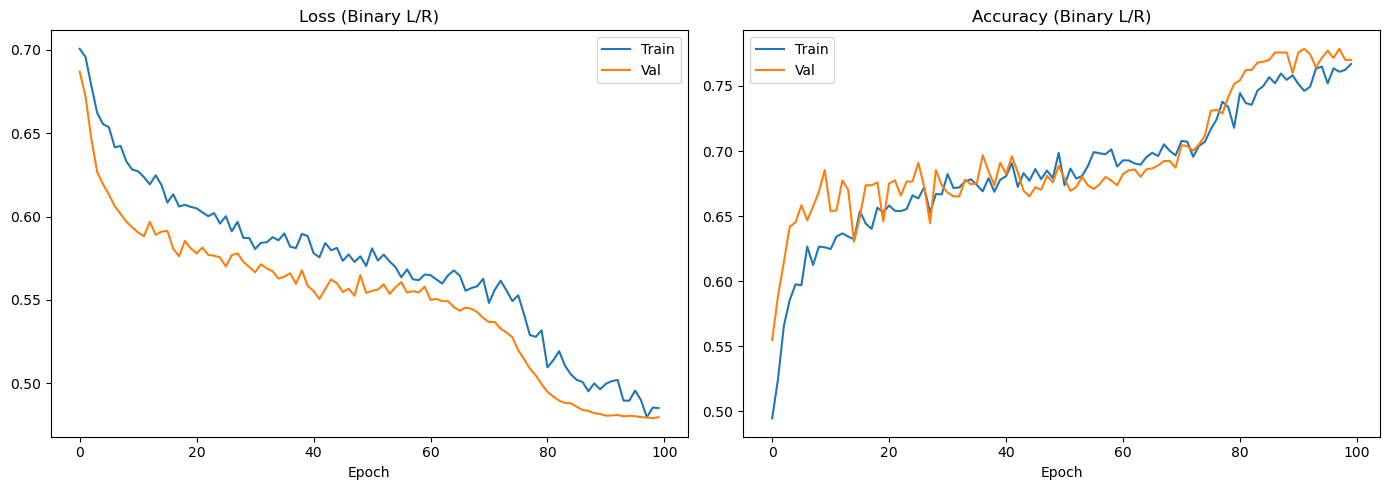


Test Accuracy:    0.7497
Balanced Accuracy: 0.7496
Cohen's Kappa:     0.4993
F1 (macro):        0.7490
F1 (weighted):     0.7490

              precision    recall  f1-score   support

   left_hand       0.73      0.80      0.76       378
  right_hand       0.78      0.70      0.74       377

    accuracy                           0.75       755
   macro avg       0.75      0.75      0.75       755
weighted avg       0.75      0.75      0.75       755



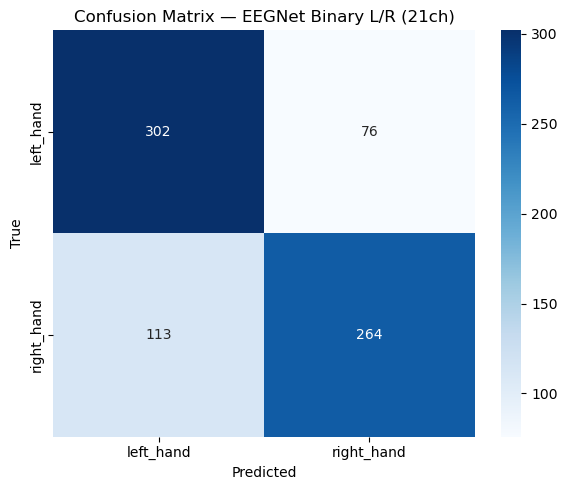

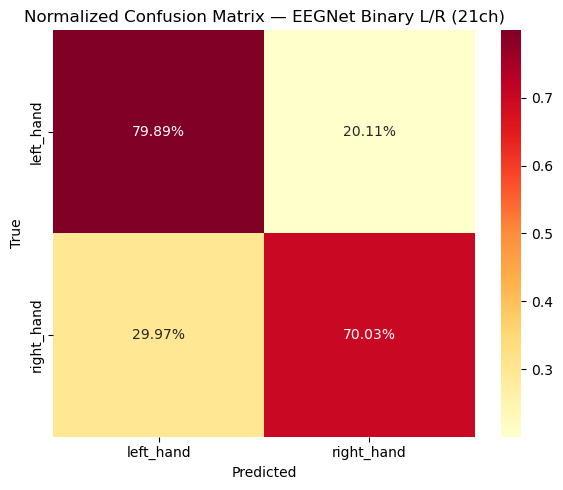

  💾 Saved: models/eegnet_21ch_binary_lr_single_run.pth
  📊 Registered: binary_lr_21ch / EEGNet / EEGNet_single_run → test_acc=0.7497


{'timestamp': '2026-03-16T20:27:17.922547',
 'experiment': 'binary_lr_21ch',
 'approach': 'EEGNet',
 'model_name': 'EEGNet_single_run',
 'test_accuracy': 0.7496688741721854,
 'test_loss': None,
 'cv_mean_accuracy': None,
 'cv_std_accuracy': None,
 'cv_fold_accuracies': None,
 'precision_per_class': {'left_hand': 0.727710843373494,
  'right_hand': 0.7764705882352941},
 'recall_per_class': {'left_hand': 0.798941798941799,
  'right_hand': 0.7002652519893899},
 'f1_per_class': {'left_hand': 0.7616645649432535,
  'right_hand': 0.7364016736401674},
 'confusion_matrix': [[302, 76], [113, 264]],
 'classification_report': None,
 'train_history': None,
 'best_params': None,
 'n_train_epochs': 3284,
 'n_test_epochs': 755,
 'balanced_accuracy': np.float64(0.7496035254655944),
 'cohen_kappa': np.float64(0.49927186595315376),
 'f1_macro': np.float64(0.7490331192917105)}

In [65]:
train_loader_lr, val_loader_lr, test_loader_lr = make_loaders(split_lr)

eeg_net_lr = EEGNet(chans=21, classes=2).to(device)

cw_lr = compute_class_weight('balanced', classes=np.unique(split_lr['y_train']),
                              y=split_lr['y_train'])
loss_fn_lr = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_lr, dtype=torch.float32).to(device)
)

optimizer_lr = torch.optim.Adam(eeg_net_lr.parameters(), lr=0.001)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_lr, T_max=100)

results_lr, _ = train_model(
    model=eeg_net_lr,
    train_loader=train_loader_lr,
    val_loader=val_loader_lr,
    test_loader=test_loader_lr,
    optimizer=optimizer_lr,
    loss_fn=loss_fn_lr,
    scheduler=scheduler_lr,
    device=device,
    epochs=100
)

plot_training_curves(results_lr, "(Binary L/R)")

metrics_lr_single, _, _ = evaluate_and_plot(
    eeg_net_lr, test_loader_lr, split_lr['y_test'],
    ['left_hand', 'right_hand'],
    'EEGNet Binary L/R (21ch)', device
)


acc_lr_single = metrics_lr_single['accuracy']
save_nn_model(eeg_net_lr, 'eegnet_21ch_binary_lr_single_run')
register_result(
    experiment='binary_lr_21ch', approach='EEGNet', model_name='EEGNet_single_run',
    test_acc=metrics_lr_single['accuracy'],
    precision=metrics_lr_single['precision_per_class'],
    recall=metrics_lr_single['recall_per_class'],
    f1=metrics_lr_single['f1_per_class'],
    confusion_mat=metrics_lr_single['confusion_matrix'],
    n_train=len(split_lr['y_train']), n_test=len(split_lr['y_test']),
    extra={'balanced_accuracy': metrics_lr_single['balanced_accuracy'],
           'cohen_kappa': metrics_lr_single['cohen_kappa'],
           'f1_macro': metrics_lr_single['f1_macro']},
)


## 30. CV + Grid Search (Binary L/R)

In [66]:
fold_results_lr, mean_acc_lr, std_acc_lr = cross_validate_subjects(
    split_lr['X_cv'], split_lr['y_cv'], split_lr['subjects_cv'],
    n_splits=5, epochs=50, lr=0.001, chans=21, classes=2
,
    cv_label='EEGNet_binary_lr_21ch_5fold'
)


Fold 1/5: train=3151, val=798
Fold 1 best val_acc: 0.6127

Fold 2/5: train=3151, val=798
Fold 2 best val_acc: 0.6667

Fold 3/5: train=3192, val=757
Fold 3 best val_acc: 0.6576

Fold 4/5: train=3151, val=798
Fold 4 best val_acc: 0.6715

Fold 5/5: train=3151, val=798
Fold 5 best val_acc: 0.6945

CV: 0.6606 ± 0.0268


In [67]:
param_grid = {
    'lr':           [0.005, 0.001, 0.0005],
    'dropout_rate': [0.25, 0.5],
    'f1':           [8, 16],
    'd':            [2, 4],
}

keys = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values()))
print(f"Total combinations: {len(combos)}")

grid_results_lr = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    f2 = params['f1'] * params['d']
    print(f"\nCombo {i+1}/{len(combos)}: {params}, f2={f2}")

    _, mean_acc, std_acc = cross_validate_subjects(
        split_lr['X_cv'], split_lr['y_cv'], split_lr['subjects_cv'],
        n_splits=3, epochs=30,
        lr=params['lr'], dropout_rate=params['dropout_rate'],
        f1=params['f1'], f2=f2, d=params['d'],
        chans=21, classes=2, verbose=False
    )
    grid_results_lr.append({**params, 'f2': f2, 'mean_acc': mean_acc, 'std_acc': std_acc})
    print(f"  → {mean_acc:.4f} ± {std_acc:.4f}")

grid_df_lr = pd.DataFrame(grid_results_lr).sort_values('mean_acc', ascending=False)
print("\nBinary L/R Grid Search Results:")
print(grid_df_lr.to_string(index=False))


Total combinations: 24

Combo 1/24: {'lr': 0.005, 'dropout_rate': 0.25, 'f1': 8, 'd': 2}, f2=16
  → 0.6969 ± 0.0426

Combo 2/24: {'lr': 0.005, 'dropout_rate': 0.25, 'f1': 8, 'd': 4}, f2=32
  → 0.7396 ± 0.0582

Combo 3/24: {'lr': 0.005, 'dropout_rate': 0.25, 'f1': 16, 'd': 2}, f2=32
  → 0.6589 ± 0.0292

Combo 4/24: {'lr': 0.005, 'dropout_rate': 0.25, 'f1': 16, 'd': 4}, f2=64
  → 0.7137 ± 0.0208

Combo 5/24: {'lr': 0.005, 'dropout_rate': 0.5, 'f1': 8, 'd': 2}, f2=16
  → 0.6672 ± 0.0224

Combo 6/24: {'lr': 0.005, 'dropout_rate': 0.5, 'f1': 8, 'd': 4}, f2=32
  → 0.6591 ± 0.0251

Combo 7/24: {'lr': 0.005, 'dropout_rate': 0.5, 'f1': 16, 'd': 2}, f2=32
  → 0.6563 ± 0.0267

Combo 8/24: {'lr': 0.005, 'dropout_rate': 0.5, 'f1': 16, 'd': 4}, f2=64
  → 0.6682 ± 0.0312

Combo 9/24: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 8, 'd': 2}, f2=16
  → 0.6569 ± 0.0141

Combo 10/24: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 8, 'd': 4}, f2=32
  → 0.6692 ± 0.0122

Combo 11/24: {'lr': 0.001, 'dropout_rate': 0.

## 31. Final EEGNet (Binary L/R)

Best: {'lr': 0.001, 'dropout_rate': 0.25, 'f1': 16.0, 'd': 4.0, 'f2': 64.0, 'mean_acc': 0.7430004409171076, 'std_acc': 0.05646513170889004}


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch:   1 | train_loss: 0.7026 | train_acc: 0.5026 | val_loss: 0.6761 | val_acc: 0.5909
Epoch:   2 | train_loss: 0.6669 | train_acc: 0.5875 | val_loss: 0.6372 | val_acc: 0.6003
Epoch:   3 | train_loss: 0.6273 | train_acc: 0.6325 | val_loss: 0.6198 | val_acc: 0.6290
Epoch:   4 | train_loss: 0.6107 | train_acc: 0.6602 | val_loss: 0.6018 | val_acc: 0.6376
Epoch:   5 | train_loss: 0.5948 | train_acc: 0.6720 | val_loss: 0.5911 | val_acc: 0.6483
Epoch:   6 | train_loss: 0.5834 | train_acc: 0.6734 | val_loss: 0.5929 | val_acc: 0.6862
Epoch:   7 | train_loss: 0.5685 | train_acc: 0.6953 | val_loss: 0.5635 | val_acc: 0.7040
Epoch:   8 | train_loss: 0.5528 | train_acc: 0.7025 | val_loss: 0.5704 | val_acc: 0.7083
Epoch:   9 | train_loss: 0.5406 | train_acc: 0.7267 | val_loss: 0.5522 | val_acc: 0.7118
Epoch:  10 | train_loss: 0.5325 | train_acc: 0.7325 | val_loss: 0.5415 | val_acc: 0.7233
Epoch:  11 | train_loss: 0.5151 | train_acc: 0.7425 | val_loss: 0.5550 | val_acc: 0.6998
Epoch:  12 | train_lo

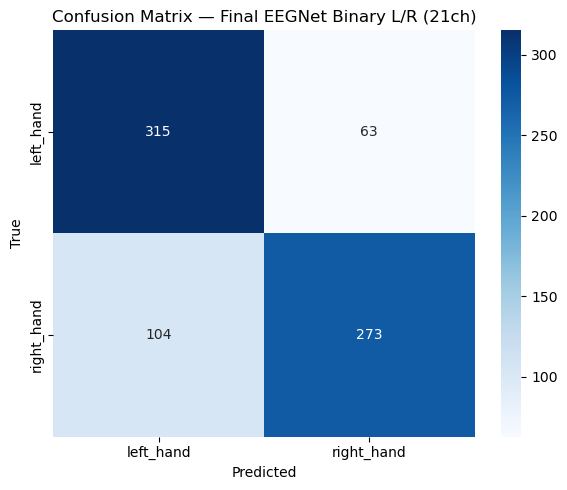

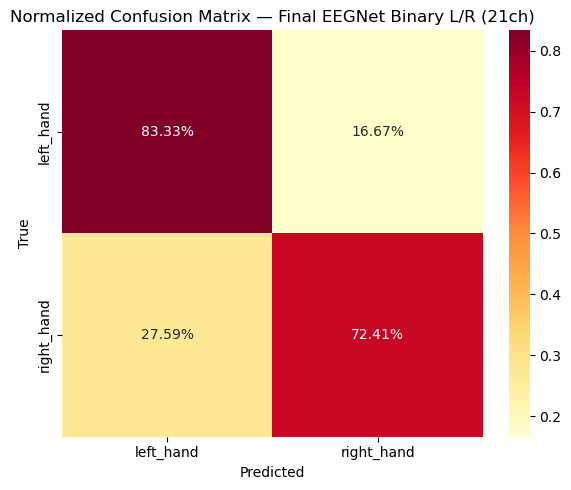

  💾 Saved: models/eegnet_21ch_binary_lr_best_grid.pth
  📊 Registered: binary_lr_21ch / EEGNet / EEGNet_best_grid → test_acc=0.7788


{'timestamp': '2026-03-16T20:36:19.221624',
 'experiment': 'binary_lr_21ch',
 'approach': 'EEGNet',
 'model_name': 'EEGNet_best_grid',
 'test_accuracy': 0.7788079470198676,
 'test_loss': None,
 'cv_mean_accuracy': None,
 'cv_std_accuracy': None,
 'cv_fold_accuracies': None,
 'precision_per_class': {'left_hand': 0.7517899761336515,
  'right_hand': 0.8125},
 'recall_per_class': {'left_hand': 0.8333333333333334,
  'right_hand': 0.7241379310344828},
 'f1_per_class': {'left_hand': 0.7904642409033877,
  'right_hand': 0.7657784011220197},
 'confusion_matrix': [[315, 63], [104, 273]],
 'classification_report': None,
 'train_history': None,
 'best_params': {'lr': 0.001,
  'dropout_rate': 0.25,
  'f1': 16.0,
  'd': 4.0,
  'f2': 64.0,
  'mean_acc': 0.7430004409171076,
  'std_acc': 0.05646513170889004},
 'n_train_epochs': 3284,
 'n_test_epochs': 755,
 'balanced_accuracy': np.float64(0.7787356321839081),
 'cohen_kappa': np.float64(0.5575514701495942),
 'f1_macro': np.float64(0.7781213210127037)}

In [68]:
best_lr = grid_df_lr.iloc[0].to_dict()
print(f"Best: {best_lr}")

final_model_lr = EEGNet(
    chans=21, classes=2,
    f1=int(best_lr['f1']), f2=int(best_lr['f2']),
    d=int(best_lr['d']), dropout_rate=best_lr['dropout_rate'],
).to(device)

optimizer = torch.optim.Adam(final_model_lr.parameters(), lr=best_lr['lr'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
loss_fn = nn.CrossEntropyLoss(
    weight=torch.tensor(
        compute_class_weight('balanced', classes=np.unique(split_lr['y_train']),
                             y=split_lr['y_train']),
        dtype=torch.float32
    ).to(device)
)

results_final_lr, _ = train_model(
    model=final_model_lr,
    train_loader=train_loader_lr,
    val_loader=val_loader_lr,
    test_loader=test_loader_lr,
    optimizer=optimizer,
    loss_fn=loss_fn,
    scheduler=scheduler,
    device=device,
    epochs=50
)

metrics_lr_final, _, _ = evaluate_and_plot(
    final_model_lr, test_loader_lr, split_lr['y_test'],
    ['left_hand', 'right_hand'],
    'Final EEGNet Binary L/R (21ch)', device
)


acc_lr_final = metrics_lr_final['accuracy']
save_nn_model(final_model_lr, 'eegnet_21ch_binary_lr_best_grid', meta={'best_params': best_lr})
register_result(
    experiment='binary_lr_21ch', approach='EEGNet', model_name='EEGNet_best_grid',
    test_acc=metrics_lr_final['accuracy'],
    precision=metrics_lr_final['precision_per_class'],
    recall=metrics_lr_final['recall_per_class'],
    f1=metrics_lr_final['f1_per_class'],
    confusion_mat=metrics_lr_final['confusion_matrix'],
    best_params=best_lr,
    n_train=len(split_lr['y_train']), n_test=len(split_lr['y_test']),
    extra={'balanced_accuracy': metrics_lr_final['balanced_accuracy'],
           'cohen_kappa': metrics_lr_final['cohen_kappa'],
           'f1_macro': metrics_lr_final['f1_macro']},
)


## 32. CSP + ML Grid Search (Binary L/R)


############################################################
  LDA
############################################################
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 27 (2.2e-16 eps * 21 dim * 5.7e+15  max singular value)
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=

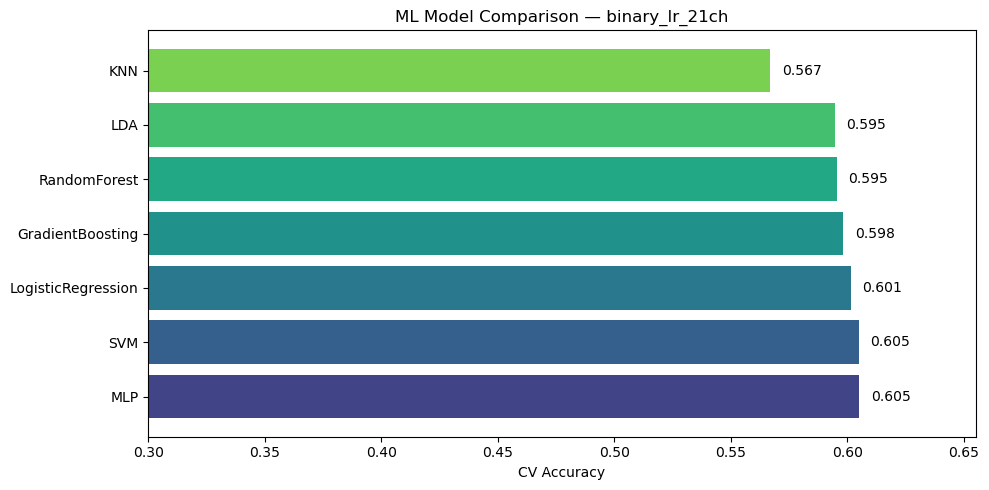


Best ML: MLP
Test Accuracy:     0.6146
Balanced Accuracy: 0.6144
Cohen's Kappa:     0.2288
              precision    recall  f1-score   support

   left_hand       0.59      0.77      0.67       378
  right_hand       0.67      0.46      0.54       377

    accuracy                           0.61       755
   macro avg       0.63      0.61      0.60       755
weighted avg       0.63      0.61      0.61       755

  💾 Saved: models/best_ml_binary_lr_21ch.pkl
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+LDA → test_acc=0.6291
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+SVM → test_acc=0.6424
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+RandomForest → test_acc=0.6212
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+KNN → test_acc=0.5815
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+GradientBoosting → test_acc=0.6026
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+LogisticRegression → test_acc=0.6318
  📊 Registered: binary_lr_21ch / CSP+ML / CSP+MLP → test_acc=0.6146


In [69]:
# For binary, standard CSP works directly (no pairwise needed)
def get_ml_models_binary():
    """Same models but with CSP n_components up to 8 (binary allows more)."""
    models = get_ml_models()
    for name, config in models.items():
        if isinstance(config['params'], list):
            for p in config['params']:
                p['csp__n_components'] = [4, 6, 8]
        else:
            config['params']['csp__n_components'] = [4, 6, 8]
    return models


ml_results_lr, ml_df_lr, ml_test_acc_lr = run_ml_grid_search(
    split_lr['X_cv'], split_lr['y_cv'], split_lr['subjects_cv'],
    split_lr['X_test'], split_lr['y_test'],
    models=get_ml_models_binary(),
    csp_class=CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False),
    target_names=['left_hand', 'right_hand'],
    experiment_label='binary_lr_21ch',
)


---
# PART E: Preprocessing Grid Search

## 33. Parameterized Epoching for Preprocessing Search

**FIX:** The preprocessing grid search now only uses train+val subjects 
(via CV). Test subjects are completely excluded from parameter selection.


In [70]:
def epoch_cv_subjects_only(raw_data, low_freq, high_freq, tmin, tmax, baseline):
    """
    Epoch ONLY train+val subjects for preprocessing search.
    Test subjects are excluded entirely to prevent leakage.
    """
    # Filter raw_data to only include train+val subjects
    cv_subject_ids = GLOBAL_TRAIN_SUBJECTS | GLOBAL_VAL_SUBJECTS
    raw_data_cv = {s: raw_data[s] for s in raw_data 
                   if s in cv_subject_ids}
    
    event_id_binary = {'left_hand': 2, 'right_hand': 3}
    
    X, y, subjects = epoch_all_subjects(
        raw_data_cv, event_id_binary,
        low_freq=low_freq, high_freq=high_freq,
        tmin=tmin, tmax=tmax, baseline=baseline,
        channels=MOTOR_CHANNELS,
    )
    return X, y, subjects


def cv_for_preprocessing(X, y, subjects, n_splits=3, epochs=30,
                         lr=0.001, chans=21, classes=2):
    time_points = X.shape[2]
    gkf = GroupKFold(n_splits=n_splits)
    fold_accs = []

    for train_idx, val_idx in gkf.split(X, y, groups=subjects):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_vl, y_vl = X[val_idx], y[val_idx]

        train_dl = DataLoader(EEGDataset(X_tr, y_tr), batch_size=64, shuffle=True)
        val_dl   = DataLoader(EEGDataset(X_vl, y_vl), batch_size=64, shuffle=False)

        model = EEGNet(chans=chans, classes=classes,
                       time_points=time_points).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        loss_fn = nn.CrossEntropyLoss(
            weight=torch.tensor(weights, dtype=torch.float32).to(device))

        best_val_acc = 0.0
        for _ in range(epochs):
            train_step(model, train_dl, loss_fn, optimizer, device)
            scheduler.step()
            _, val_acc = eval_step(model, val_dl, loss_fn, device)
            if val_acc > best_val_acc:
                best_val_acc = val_acc
        fold_accs.append(best_val_acc)

    return np.mean(fold_accs), np.std(fold_accs)


## 34. Run Preprocessing Grid Search

In [71]:
preprocessing_grid = {
    'bandpass': [
        (8, 12),     # mu only
        (13, 30),    # beta only
        (8, 30),     # mu + beta
        (7, 30),     # current baseline
        (4, 40),     # wide
    ],
    'time_window': [
        (0.0, 4.0),
        (0.5, 3.5),
        (0.5, 2.5),
        (1.0, 3.0),
    ],
    'baseline': [
        None,
        (None, 0),
    ],
}

total_combos = (len(preprocessing_grid['bandpass'])
                * len(preprocessing_grid['time_window'])
                * len(preprocessing_grid['baseline']))
print(f"Total preprocessing combinations: {total_combos}")

preproc_results = []
combo_num = 0

for low_freq, high_freq in preprocessing_grid['bandpass']:
    for tmin, tmax in preprocessing_grid['time_window']:
        for baseline in preprocessing_grid['baseline']:
            combo_num += 1
            actual_tmin = tmin
            if baseline == (None, 0) and tmin >= 0:
                actual_tmin = -0.5

            label = f"bp={low_freq}-{high_freq}Hz, t={actual_tmin}-{tmax}s, bl={'yes' if baseline else 'no'}"
            print(f"\nCombo {combo_num}/{total_combos}: {label}")

            start = time.time()
            try:
                # FIX: only CV subjects
                X, y, subjects = epoch_cv_subjects_only(
                    raw_data, low_freq, high_freq, actual_tmin, tmax, baseline)

                mean_acc, std_acc = cv_for_preprocessing(X, y, subjects)
                elapsed = time.time() - start
                print(f"  → {mean_acc:.4f} ± {std_acc:.4f} ({elapsed:.0f}s)")

                preproc_results.append({
                    'low_freq': low_freq, 'high_freq': high_freq,
                    'tmin': actual_tmin, 'tmax': tmax,
                    'baseline': 'yes' if baseline else 'no',
                    'time_points': X.shape[2], 'n_epochs': X.shape[0],
                    'mean_acc': mean_acc, 'std_acc': std_acc, 'time_s': elapsed,
                })
            except Exception as e:
                print(f"  ✗ FAILED: {e}")

preproc_df = pd.DataFrame(preproc_results).dropna(subset=['mean_acc'])
preproc_df = preproc_df.sort_values('mean_acc', ascending=False)
print("\nTop 10 preprocessing combos:")
print(preproc_df.head(10).to_string(index=False))


Total preprocessing combinations: 40

Combo 1/40: bp=8-12Hz, t=0.0-4.0s, bl=no
  → 0.6295 ± 0.0162 (17s)

Combo 2/40: bp=8-12Hz, t=-0.5-4.0s, bl=yes
  → 0.6297 ± 0.0240 (19s)

Combo 3/40: bp=8-12Hz, t=0.5-3.5s, bl=no
  → 0.6309 ± 0.0137 (14s)

Combo 4/40: bp=8-12Hz, t=-0.5-3.5s, bl=yes
  → 0.6236 ± 0.0234 (17s)

Combo 5/40: bp=8-12Hz, t=0.5-2.5s, bl=no
  → 0.6248 ± 0.0137 (11s)

Combo 6/40: bp=8-12Hz, t=-0.5-2.5s, bl=yes
  → 0.6164 ± 0.0107 (14s)

Combo 7/40: bp=8-12Hz, t=1.0-3.0s, bl=no
  → 0.6014 ± 0.0085 (11s)

Combo 8/40: bp=8-12Hz, t=-0.5-3.0s, bl=yes
  → 0.6281 ± 0.0183 (16s)

Combo 9/40: bp=13-30Hz, t=0.0-4.0s, bl=no
  → 0.6415 ± 0.0040 (18s)

Combo 10/40: bp=13-30Hz, t=-0.5-4.0s, bl=yes
  → 0.6346 ± 0.0170 (19s)

Combo 11/40: bp=13-30Hz, t=0.5-3.5s, bl=no
  → 0.6364 ± 0.0114 (14s)

Combo 12/40: bp=13-30Hz, t=-0.5-3.5s, bl=yes
  → 0.6268 ± 0.0104 (18s)

Combo 13/40: bp=13-30Hz, t=0.5-2.5s, bl=no
  → 0.6254 ± 0.0298 (12s)

Combo 14/40: bp=13-30Hz, t=-0.5-2.5s, bl=yes
  → 0.6248 ±

## 35. Preprocessing Visualization

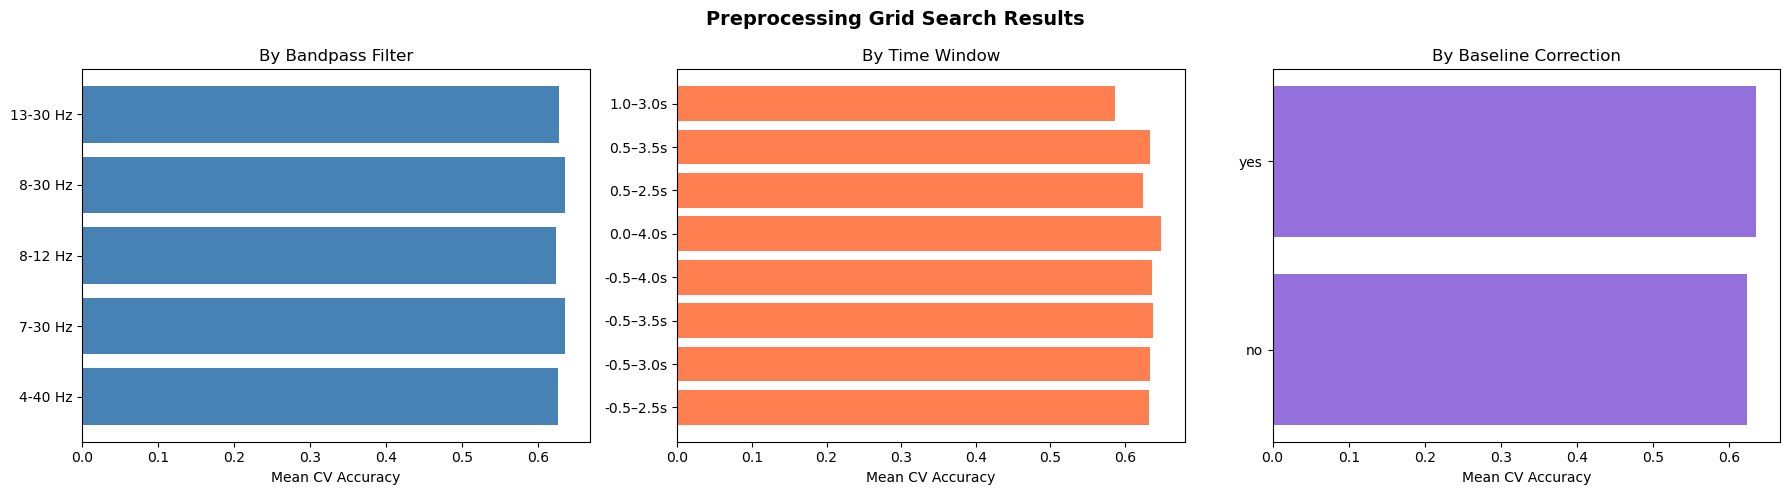

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bp_groups = preproc_df.groupby(['low_freq', 'high_freq'])['mean_acc'].mean()
bp_labels = [f"{int(l)}-{int(h)} Hz" for l, h in bp_groups.index]
axes[0].barh(bp_labels, bp_groups.values, color='steelblue')
axes[0].set_xlabel('Mean CV Accuracy')
axes[0].set_title('By Bandpass Filter')

tw_groups = preproc_df.groupby(['tmin', 'tmax'])['mean_acc'].mean()
tw_labels = [f"{t0}–{t1}s" for t0, t1 in tw_groups.index]
axes[1].barh(tw_labels, tw_groups.values, color='coral')
axes[1].set_xlabel('Mean CV Accuracy')
axes[1].set_title('By Time Window')

bl_groups = preproc_df.groupby('baseline')['mean_acc'].mean()
axes[2].barh(bl_groups.index, bl_groups.values, color='mediumpurple')
axes[2].set_xlabel('Mean CV Accuracy')
axes[2].set_title('By Baseline Correction')

plt.suptitle('Preprocessing Grid Search Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


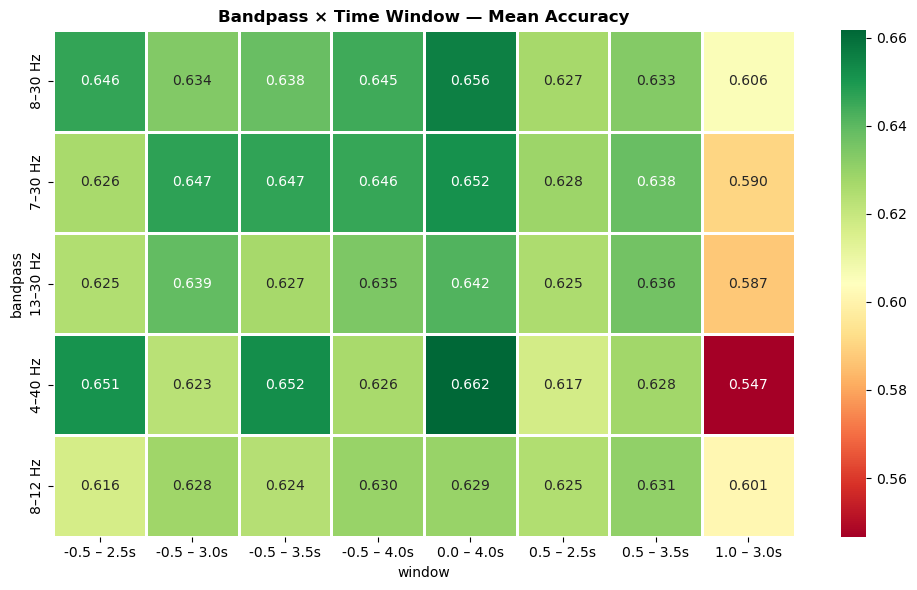

In [73]:
# Heatmap
preproc_df_plot = preproc_df.copy()
preproc_df_plot['bandpass'] = (preproc_df_plot['low_freq'].astype(int).astype(str) + '–' +
                               preproc_df_plot['high_freq'].astype(int).astype(str) + ' Hz')
preproc_df_plot['window'] = (preproc_df_plot['tmin'].astype(str) + ' – ' +
                             preproc_df_plot['tmax'].astype(str) + 's')

pivot = preproc_df_plot.pivot_table(values='mean_acc', index='bandpass',
                                     columns='window', aggfunc='mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=1, linecolor='white')
plt.title('Bandpass × Time Window — Mean Accuracy', fontweight='bold')
plt.tight_layout()
plt.show()


---
# PART F: Joint Grid Search — Preprocessing × All Models

## 36. Top Preprocessing Combos × EEGNet + ML

**FIX:** Uses only train+val subjects for preprocessing search. 
Test subjects are untouched until final evaluation.


In [74]:
TOP_N = 5
top_preproc = preproc_df.head(TOP_N).copy()
print(f"Top {TOP_N} preprocessing combos:")
for i, (_, row) in enumerate(top_preproc.iterrows()):
    print(f"  #{i+1}: bp={int(row['low_freq'])}-{int(row['high_freq'])}Hz, "
          f"t={row['tmin']}-{row['tmax']}s, bl={row['baseline']}, "
          f"acc={row['mean_acc']:.4f}")


Top 5 preprocessing combos:
  #1: bp=4-40Hz, t=0.0-4.0s, bl=no, acc=0.6617
  #2: bp=8-30Hz, t=0.0-4.0s, bl=no, acc=0.6556
  #3: bp=4-40Hz, t=-0.5-3.5s, bl=yes, acc=0.6524
  #4: bp=7-30Hz, t=0.0-4.0s, bl=no, acc=0.6516
  #5: bp=4-40Hz, t=-0.5-2.5s, bl=yes, acc=0.6512


In [75]:
def run_eegnet_grid_light(X, y, subjects, chans=21, classes=2,
                          n_splits=3, epochs_train=30):
    time_points = X.shape[2]
    param_grid = {
        'lr':           [0.001, 0.0005],
        'dropout_rate': [0.25, 0.5],
        'f1':           [8, 16],
        'd':            [2],
    }
    keys = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    results = []

    for combo in combos:
        params = dict(zip(keys, combo))
        f2 = params['f1'] * params['d']
        gkf = GroupKFold(n_splits=n_splits)
        fold_accs = []

        for train_idx, val_idx in gkf.split(X, y, groups=subjects):
            X_tr, y_tr = X[train_idx], y[train_idx]
            X_vl, y_vl = X[val_idx], y[val_idx]
            train_dl = DataLoader(EEGDataset(X_tr, y_tr), batch_size=64, shuffle=True)
            val_dl   = DataLoader(EEGDataset(X_vl, y_vl), batch_size=64, shuffle=False)

            model = EEGNet(chans=chans, classes=classes, time_points=time_points,
                           f1=params['f1'], f2=f2, d=params['d'],
                           dropout_rate=params['dropout_rate']).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_train)
            weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
            loss_fn = nn.CrossEntropyLoss(
                weight=torch.tensor(weights, dtype=torch.float32).to(device))

            best_val = 0.0
            for _ in range(epochs_train):
                train_step(model, train_dl, loss_fn, optimizer, device)
                scheduler.step()
                _, val_acc = eval_step(model, val_dl, loss_fn, device)
                if val_acc > best_val:
                    best_val = val_acc
            fold_accs.append(best_val)

        results.append({
            'model_type': 'EEGNet',
            'model_name': f"EEGNet(f1={params['f1']},d={params['d']},"
                          f"do={params['dropout_rate']},lr={params['lr']})",
            'mean_acc': np.mean(fold_accs),
            'std_acc': np.std(fold_accs),
            'params': {**params, 'f2': f2},
        })
    return results


def run_ml_grid_light(X, y, subjects, n_splits=3):
    gkf = GroupKFold(n_splits=n_splits)
    models = {
        'LDA': {
            'model': LinearDiscriminantAnalysis(),
            'params': [
                {'classifier__solver': ['svd'], 'classifier__shrinkage': [None],
                 'csp__n_components': [4, 6]},
                {'classifier__solver': ['lsqr'], 'classifier__shrinkage': [None, 'auto'],
                 'csp__n_components': [4, 6]},
            ]
        },
        'SVM': {
            'model': SVC(probability=True, random_state=42, class_weight='balanced'),
            'params': {'classifier__C': [0.1, 1.0, 10.0],
                       'classifier__kernel': ['rbf', 'linear'],
                       'csp__n_components': [4, 6]},
        },
        'RandomForest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {'classifier__n_estimators': [100, 200],
                       'classifier__max_depth': [5, 10, None],
                       'csp__n_components': [4, 6]},
        },
        'KNN': {
            'model': KNeighborsClassifier(),
            'params': {'classifier__n_neighbors': [3, 5, 7],
                       'classifier__weights': ['uniform', 'distance'],
                       'csp__n_components': [4, 6]},
        },
        'GradientBoosting': {
            'model': GradientBoostingClassifier(random_state=42),
            'params': {'classifier__n_estimators': [100, 200],
                       'classifier__learning_rate': [0.01, 0.1],
                       'classifier__max_depth': [3, 5],
                       'csp__n_components': [4, 6]},
        },
        'LogisticRegression': {
            'model': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
            'params': {'classifier__C': [0.1, 1.0, 10.0],
                       'classifier__penalty': ['l1', 'l2'],
                       'classifier__solver': ['saga'],
                       'csp__n_components': [4, 6]},
        },
        'MLP': {
            'model': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
            'params': {'classifier__hidden_layer_sizes': [(64,), (128,)],
                       'classifier__alpha': [0.0001, 0.001],
                       'csp__n_components': [4, 6]},
        },
    }
    results = []
    for name, config in models.items():
        pipe = Pipeline([
            ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
            ('scaler', StandardScaler()),
            ('classifier', config['model']),
        ])
        grid = GridSearchCV(pipe, param_grid=config['params'],
                            cv=gkf, scoring='accuracy', n_jobs=-1, verbose=0)
        try:
            grid.fit(X, y, groups=subjects)
            results.append({
                'model_type': 'CSP+ML',
                'model_name': f'CSP+{name}',
                'mean_acc': grid.best_score_,
                'std_acc': grid.cv_results_['std_test_score'][grid.best_index_],
                'params': grid.best_params_,
            })
        except Exception as e:
            print(f"  ✗ {name}: {e}")
    return results


all_joint_results = []

for pp_idx, (_, pp_row) in enumerate(top_preproc.iterrows()):
    pp_label = (f"bp={int(pp_row['low_freq'])}-{int(pp_row['high_freq'])}Hz, "
                f"t={pp_row['tmin']}-{pp_row['tmax']}s, bl={pp_row['baseline']}")
    print(f"\n{'='*70}")
    print(f"  PREPROCESSING {pp_idx+1}/{TOP_N}: {pp_label}")
    print(f"{'='*70}")

    baseline_param = (None, 0) if pp_row['baseline'] == 'yes' else None

    # FIX: only CV subjects for parameter search
    X, y, subjects = epoch_cv_subjects_only(
        raw_data, pp_row['low_freq'], pp_row['high_freq'],
        pp_row['tmin'], pp_row['tmax'], baseline_param)
    print(f"  Epoched: {X.shape}")

    print(f"  Running EEGNet grid...")
    start = time.time()
    eegnet_res = run_eegnet_grid_light(X, y, subjects)
    print(f"  EEGNet done ({time.time()-start:.0f}s), "
          f"best: {max(r['mean_acc'] for r in eegnet_res):.4f}")

    print(f"  Running CSP+ML grid...")
    start = time.time()
    ml_res = run_ml_grid_light(X, y, subjects)
    print(f"  ML done ({time.time()-start:.0f}s), "
          f"best: {max(r['mean_acc'] for r in ml_res):.4f}")

    for r in eegnet_res + ml_res:
        all_joint_results.append({
            'preproc': pp_label,
            'low_freq': pp_row['low_freq'], 'high_freq': pp_row['high_freq'],
            'tmin': pp_row['tmin'], 'tmax': pp_row['tmax'],
            'baseline': pp_row['baseline'],
            **{k: v for k, v in r.items()},
        })

joint_df = pd.DataFrame(all_joint_results).sort_values('mean_acc', ascending=False)
print("\nTop 20 (Preprocessing × Model):")
print(joint_df.head(20)[['preproc', 'model_name', 'mean_acc', 'std_acc']].to_string(index=False))

best_joint = joint_df.iloc[0]
print(f"\n🏆 GLOBAL BEST: {best_joint['model_name']} | {best_joint['preproc']} | "
      f"acc={best_joint['mean_acc']:.4f}")



  PREPROCESSING 1/5: bp=4-40Hz, t=0.0-4.0s, bl=no
  Epoched: (3950, 21, 641)
  Running EEGNet grid...
  EEGNet done (136s), best: 0.6914
  Running CSP+ML grid...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 25 (2.2e-16 eps * 21 dim * 5.3e+15  max singular value)
    Using tolerance 25 (2.2e-16 eps * 21 

## 37. Analysis Plots

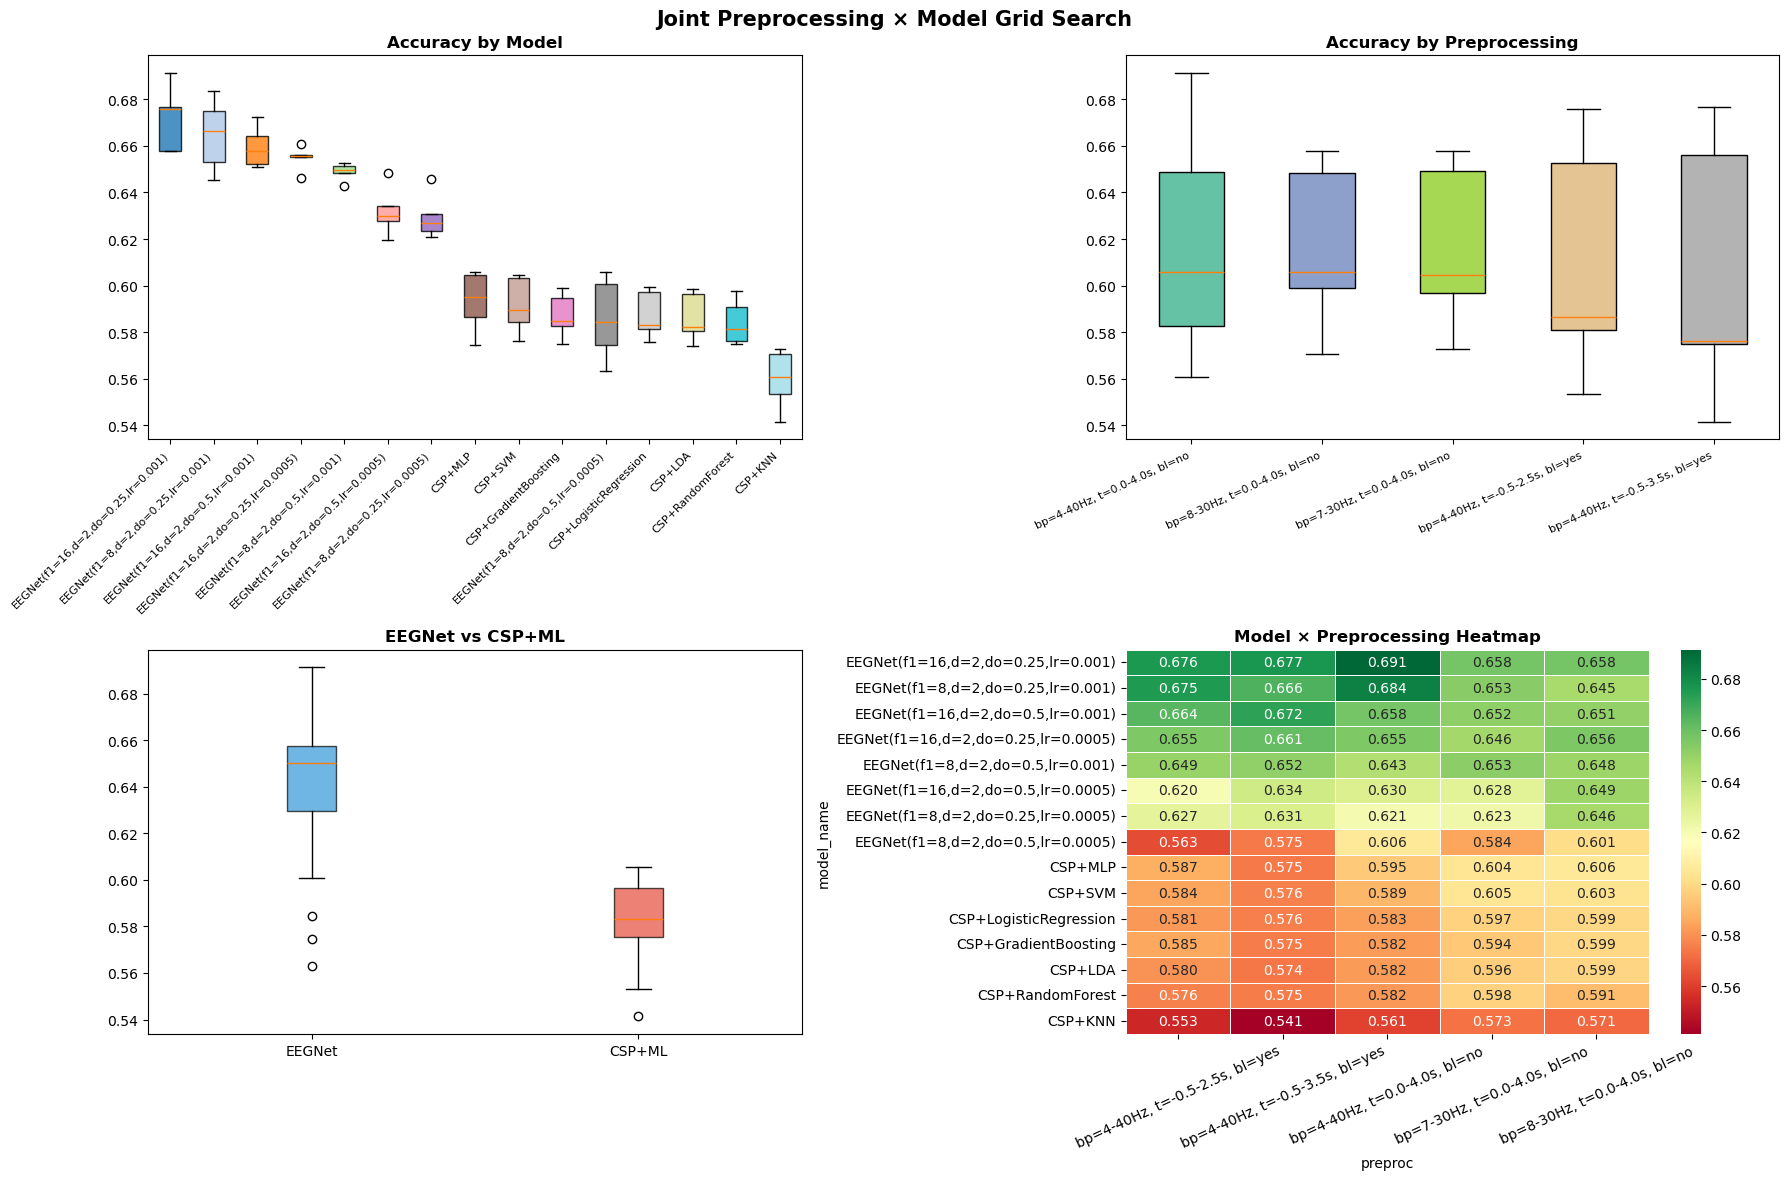

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# By model
model_order = (joint_df.groupby('model_name')['mean_acc']
               .median().sort_values(ascending=False).index.tolist())
model_data = [joint_df[joint_df['model_name'] == m]['mean_acc'].values for m in model_order]
bplot1 = axes[0, 0].boxplot(model_data, vert=True, patch_artist=True)
for patch, color in zip(bplot1['boxes'],
                        plt.cm.tab20(np.linspace(0, 1, len(model_order)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0, 0].set_xticklabels(model_order, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_title('Accuracy by Model', fontweight='bold')

# By preprocessing
pp_order = (joint_df.groupby('preproc')['mean_acc']
            .median().sort_values(ascending=False).index.tolist())
pp_data = [joint_df[joint_df['preproc'] == p]['mean_acc'].values for p in pp_order]
bplot2 = axes[0, 1].boxplot(pp_data, vert=True, patch_artist=True)
for patch, color in zip(bplot2['boxes'],
                        plt.cm.Set2(np.linspace(0, 1, len(pp_order)))):
    patch.set_facecolor(color)
axes[0, 1].set_xticklabels(pp_order, rotation=25, ha='right', fontsize=8)
axes[0, 1].set_title('Accuracy by Preprocessing', fontweight='bold')

# EEGNet vs ML
type_order = ['EEGNet', 'CSP+ML']
type_data = [joint_df[joint_df['model_type'] == t]['mean_acc'].values for t in type_order]
bplot3 = axes[1, 0].boxplot(type_data, vert=True, patch_artist=True, labels=type_order)
for patch, color in zip(bplot3['boxes'], ['#3498db', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('EEGNet vs CSP+ML', fontweight='bold')

# Heatmap
pivot = joint_df.pivot_table(values='mean_acc', index='model_name',
                              columns='preproc', aggfunc='max')
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Model × Preprocessing Heatmap', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.suptitle('Joint Preprocessing × Model Grid Search', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 38. Final Evaluation — Best (Preprocessing × Model) on Held-Out Test Set

Now we re-epoch ALL subjects (including test) with the best preprocessing,
apply the global split, and do a final train → evaluate on test.


Best combo: EEGNet(f1=16,d=2,do=0.25,lr=0.001) | bp=4-40Hz, t=0.0-4.0s, bl=no
Train: 3282 epochs from 74 subjects
Val:   664 epochs from 15 subjects
Test:  758 epochs from 17 subjects


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch:   1 | train_loss: 0.7035 | train_acc: 0.5028 | val_loss: 0.6918 | val_acc: 0.5199
Epoch:   2 | train_loss: 0.6852 | train_acc: 0.5629 | val_loss: 0.6820 | val_acc: 0.5601
Epoch:   3 | train_loss: 0.6693 | train_acc: 0.5974 | val_loss: 0.6684 | val_acc: 0.6037
Epoch:   4 | train_loss: 0.6600 | train_acc: 0.6193 | val_loss: 0.6535 | val_acc: 0.6098
Epoch:   5 | train_loss: 0.6395 | train_acc: 0.6269 | val_loss: 0.6166 | val_acc: 0.6591
Epoch:   6 | train_loss: 0.6143 | train_acc: 0.6667 | val_loss: 0.5782 | val_acc: 0.6889
Epoch:   7 | train_loss: 0.6010 | train_acc: 0.6563 | val_loss: 0.5541 | val_acc: 0.7159
Epoch:   8 | train_loss: 0.5863 | train_acc: 0.6892 | val_loss: 0.5594 | val_acc: 0.7017
Epoch:   9 | train_loss: 0.5750 | train_acc: 0.6849 | val_loss: 0.5508 | val_acc: 0.6993
Epoch:  10 | train_loss: 0.5615 | train_acc: 0.7000 | val_loss: 0.5502 | val_acc: 0.6974
Epoch:  11 | train_loss: 0.5549 | train_acc: 0.7078 | val_loss: 0.5418 | val_acc: 0.7216
Epoch:  12 | train_lo

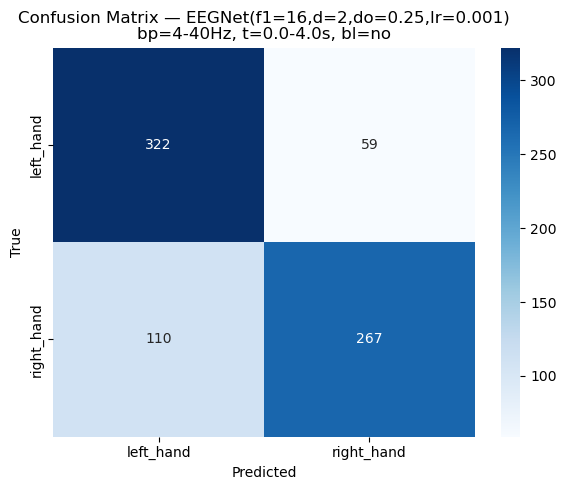

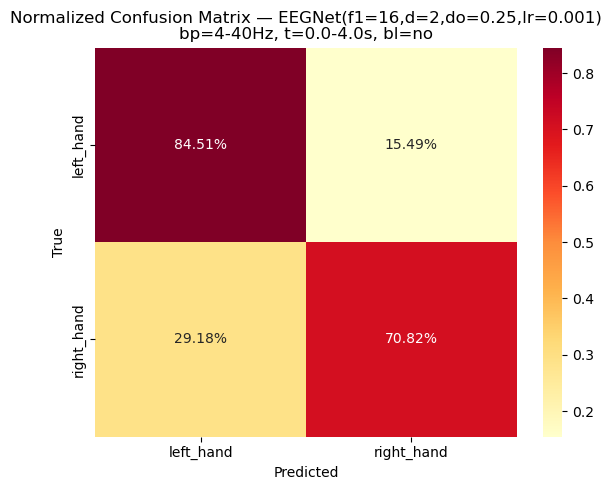


  FINAL RESULT: 0.7770


In [79]:
import re as re_module
import json

best = joint_df.iloc[0]
print(f"Best combo: {best['model_name']} | {best['preproc']}")

baseline_param = (None, 0) if best['baseline'] == 'yes' else None

# Re-epoch ALL subjects with best preprocessing
X_final, y_final, s_final = epoch_all_subjects(
    raw_data, {'left_hand': 2, 'right_hand': 3},
    low_freq=best['low_freq'], high_freq=best['high_freq'],
    tmin=best['tmin'], tmax=best['tmax'],
    baseline=baseline_param, channels=MOTOR_CHANNELS,
)

split_final = apply_global_split(X_final, y_final, s_final)
time_points = X_final.shape[2]

if best['model_type'] == 'EEGNet':
    m = re_module.search(r'f1=(\d+),d=(\d+),do=([\d.]+),lr=([\d.]+)', best['model_name'])
    f1, d, do, lr = int(m.group(1)), int(m.group(2)), float(m.group(3)), float(m.group(4))
    f2 = f1 * d

    final_model = EEGNet(chans=21, classes=2, time_points=time_points,
                         f1=f1, f2=f2, d=d, dropout_rate=do).to(device)
    
    train_dl = DataLoader(EEGDataset(split_final['X_train'], split_final['y_train']),
                          batch_size=64, shuffle=True)
    val_dl   = DataLoader(EEGDataset(split_final['X_val'], split_final['y_val']),
                          batch_size=64, shuffle=False)
    test_dl  = DataLoader(EEGDataset(split_final['X_test'], split_final['y_test']),
                          batch_size=64, shuffle=False)
    
    optimizer = torch.optim.Adam(final_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
    weights = compute_class_weight('balanced',
        classes=np.unique(split_final['y_train']), y=split_final['y_train'])
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device))

    # Train on train, early stop on val, evaluate on test
    final_results, _ = train_model(
        model=final_model, train_loader=train_dl,
        val_loader=val_dl, test_loader=test_dl,
        optimizer=optimizer, loss_fn=loss_fn,
        scheduler=scheduler, device=device, epochs=100
    )

    metrics_final, all_preds, all_labels = evaluate_and_plot(
        final_model, test_dl, split_final['y_test'],
        ['left_hand', 'right_hand'],
        f'{best["model_name"]}\n{best["preproc"]}', device
    )
    acc_final = metrics_final['accuracy']

else:
    best_ml_name = best['model_name'].replace('CSP+', '')
    ml_map = {
        'LDA': LinearDiscriminantAnalysis(),
        'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
        'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'KNN': KNeighborsClassifier(),
        'GradientBoosting': GradientBoostingClassifier(random_state=42),
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'MLP': MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    }
    
    # Train on train+val (CV already selected params)
    X_trainval = np.concatenate([split_final['X_train'], split_final['X_val']])
    y_trainval = np.concatenate([split_final['y_train'], split_final['y_val']])
    
    pipe = Pipeline([
        ('csp', CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)),
        ('scaler', StandardScaler()),
        ('classifier', ml_map[best_ml_name]),
    ])
    pipe.fit(X_trainval, y_trainval)
    
    all_preds = pipe.predict(split_final['X_test'])
    all_labels = split_final['y_test']
    acc_final = accuracy_score(all_labels, all_preds)
    
    print(f"\nTest Accuracy: {acc_final:.4f}")
    print(classification_report(all_labels, all_preds,
                                target_names=['left_hand', 'right_hand']))

print(f"\n{'='*60}")
print(f"  FINAL RESULT: {acc_final:.4f}")
print(f"{'='*60}")

## 39. Save Global Best Model + Register Final Result

In [80]:
import json

if best['model_type'] == 'EEGNet':
    save_nn_model(final_model, 'global_best_binary_lr', meta={
        "model_name": best["model_name"],
        "preproc": best["preproc"],
        "chans": 21, "classes": 2,
        "time_points": int(time_points),
        "bandpass": [float(best["low_freq"]), float(best["high_freq"])],
        "tmin": float(best["tmin"]), "tmax": float(best["tmax"]),
        "baseline": best["baseline"],
        "sfreq": 160,
        "labels": {"0": "left_hand", "1": "right_hand"},
        "test_accuracy": float(acc_final),
    })
else:
    save_sklearn_model(pipe, 'global_best_binary_lr')

# Register
register_result(
    experiment='joint_preproc_search', approach=best['model_type'],
    model_name=best['model_name'],
    test_acc=acc_final,
    n_train=len(split_final['y_train'])+len(split_final['y_val']),
    n_test=len(split_final['y_test']),
    best_params={'preproc': best['preproc']},
    extra={'preprocessing': best['preproc']},
)


  💾 Saved: models/global_best_binary_lr.pth
  📊 Registered: joint_preproc_search / EEGNet / EEGNet(f1=16,d=2,do=0.25,lr=0.001) → test_acc=0.7770


{'timestamp': '2026-03-16T21:40:09.479697',
 'experiment': 'joint_preproc_search',
 'approach': 'EEGNet',
 'model_name': 'EEGNet(f1=16,d=2,do=0.25,lr=0.001)',
 'test_accuracy': 0.7770448548812665,
 'test_loss': None,
 'cv_mean_accuracy': None,
 'cv_std_accuracy': None,
 'cv_fold_accuracies': None,
 'precision_per_class': None,
 'recall_per_class': None,
 'f1_per_class': None,
 'confusion_matrix': None,
 'classification_report': None,
 'train_history': None,
 'best_params': {'preproc': 'bp=4-40Hz, t=0.0-4.0s, bl=no'},
 'n_train_epochs': 3946,
 'n_test_epochs': 758,
 'preprocessing': 'bp=4-40Hz, t=0.0-4.0s, bl=no'}

---
# PART H: Comprehensive Results Summary & Export

## 40. Save All Metrics


In [81]:
summary_df = save_all_results()
print("\n" + "="*80)
print("  FULL RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))



📁 Results saved:
   results/all_metrics.json
   results/summary_metrics.csv
   results/cv_details.json

  FULL RESULTS SUMMARY
          experiment approach                         model_name  test_accuracy  test_loss  cv_mean   cv_std  n_train  n_test
         3class_64ch   EEGNet                  EEGNet_single_run       0.600893   0.848294      NaN      NaN     4924    1120
      binary_lr_21ch   EEGNet                  EEGNet_single_run       0.749669        NaN      NaN      NaN     3284     755
      binary_lr_21ch   EEGNet                   EEGNet_best_grid       0.778808        NaN      NaN      NaN     3284     755
      binary_lr_21ch   CSP+ML                            CSP+LDA       0.629139        NaN 0.594512 0.024646     3949     755
      binary_lr_21ch   CSP+ML                            CSP+SVM       0.642384        NaN 0.604923 0.025193     3949     755
      binary_lr_21ch   CSP+ML                   CSP+RandomForest       0.621192        NaN 0.595413 0.019745     394

## 41. Cross-Experiment Comparison Dashboard

In [82]:
# Build comparison dataframe from registry
comp_rows = []
for r in METRICS_REGISTRY:
    if r.get('test_accuracy') is not None:
        comp_rows.append({
            'Experiment': r['experiment'],
            'Approach': r['approach'],
            'Model': r['model_name'],
            'Test Acc': r['test_accuracy'],
            'Balanced Acc': r.get('balanced_accuracy'),
            'Cohen Kappa': r.get('cohen_kappa'),
            'F1 Macro': r.get('f1_macro'),
            'F1 Weighted': r.get('f1_weighted'),
            'CV Mean': r.get('cv_mean_accuracy'),
            'CV Std': r.get('cv_std_accuracy'),
        })
comp_df = pd.DataFrame(comp_rows).sort_values('Test Acc', ascending=False)

print("All registered results (sorted by test accuracy):")
print(comp_df.to_string(index=False))


All registered results (sorted by test accuracy):
          Experiment Approach                              Model  Test Acc  Balanced Acc  Cohen Kappa  F1 Macro  F1 Weighted  CV Mean   CV Std
      binary_lr_21ch   EEGNet                   EEGNet_best_grid  0.778808      0.778736     0.557551  0.778121          NaN      NaN      NaN
joint_preproc_search   EEGNet EEGNet(f1=16,d=2,do=0.25,lr=0.001)  0.777045           NaN          NaN       NaN          NaN      NaN      NaN
      binary_lr_21ch   EEGNet                  EEGNet_single_run  0.749669      0.749604     0.499272  0.749033          NaN      NaN      NaN
      binary_lr_21ch   CSP+ML                            CSP+SVM  0.642384      0.642275     0.284611  0.639877     0.639916 0.604923 0.025193
      binary_lr_21ch   CSP+ML             CSP+LogisticRegression  0.631788      0.631773     0.263554  0.631736     0.631742 0.601401 0.023941
      binary_lr_21ch   CSP+ML                            CSP+LDA  0.629139      0.629131    

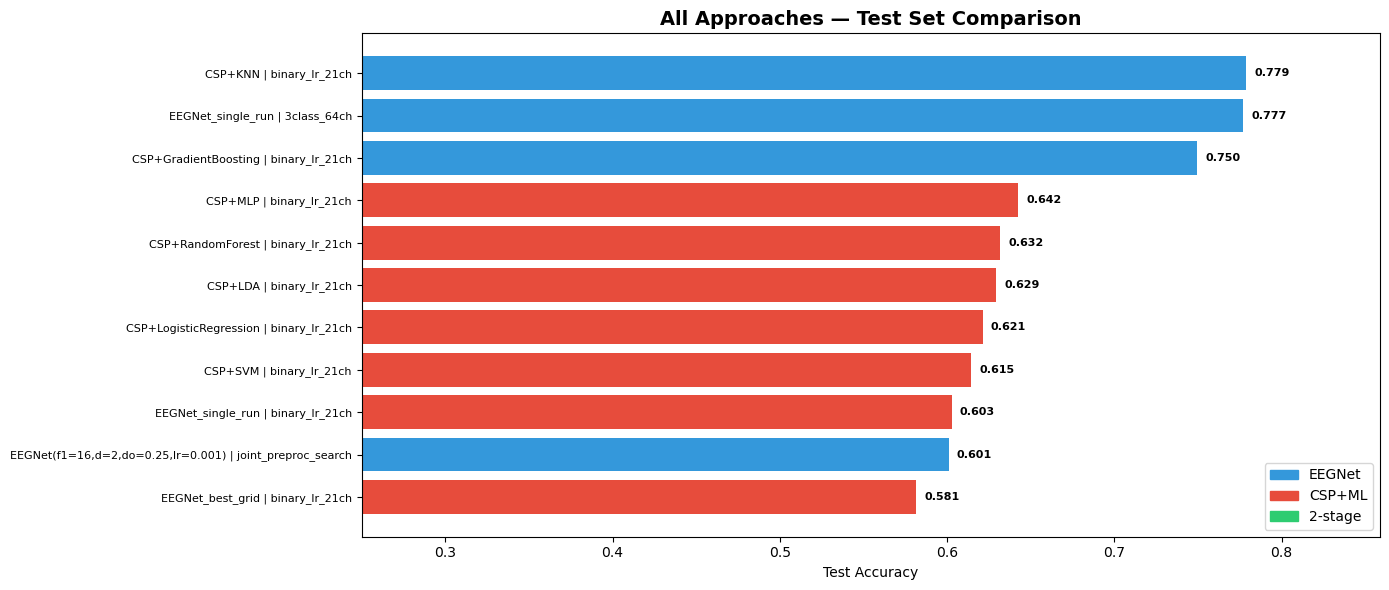

In [83]:
# ── Master comparison bar chart ──
fig, ax = plt.subplots(figsize=(14, max(6, len(comp_df) * 0.4)))

colors_map = {'EEGNet': '#3498db', 'CSP+ML': '#e74c3c', '2-stage': '#2ecc71'}
colors = [colors_map.get(a, '#95a5a6') for a in comp_df['Approach']]

labels = comp_df['Model'] + ' | ' + comp_df['Experiment']
bars = ax.barh(range(len(comp_df)), comp_df['Test Acc'].values, color=colors)

ax.set_yticks(range(len(comp_df)))
ax.set_yticklabels(labels[::-1].values, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Test Accuracy')
ax.set_title('All Approaches — Test Set Comparison', fontweight='bold', fontsize=14)
ax.set_xlim(0.25, min(1.0, comp_df['Test Acc'].max() + 0.08))

for i, (bar, acc) in enumerate(zip(bars, comp_df['Test Acc'].values)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in colors_map.items()],
          loc='lower right')
plt.tight_layout()
plt.show()


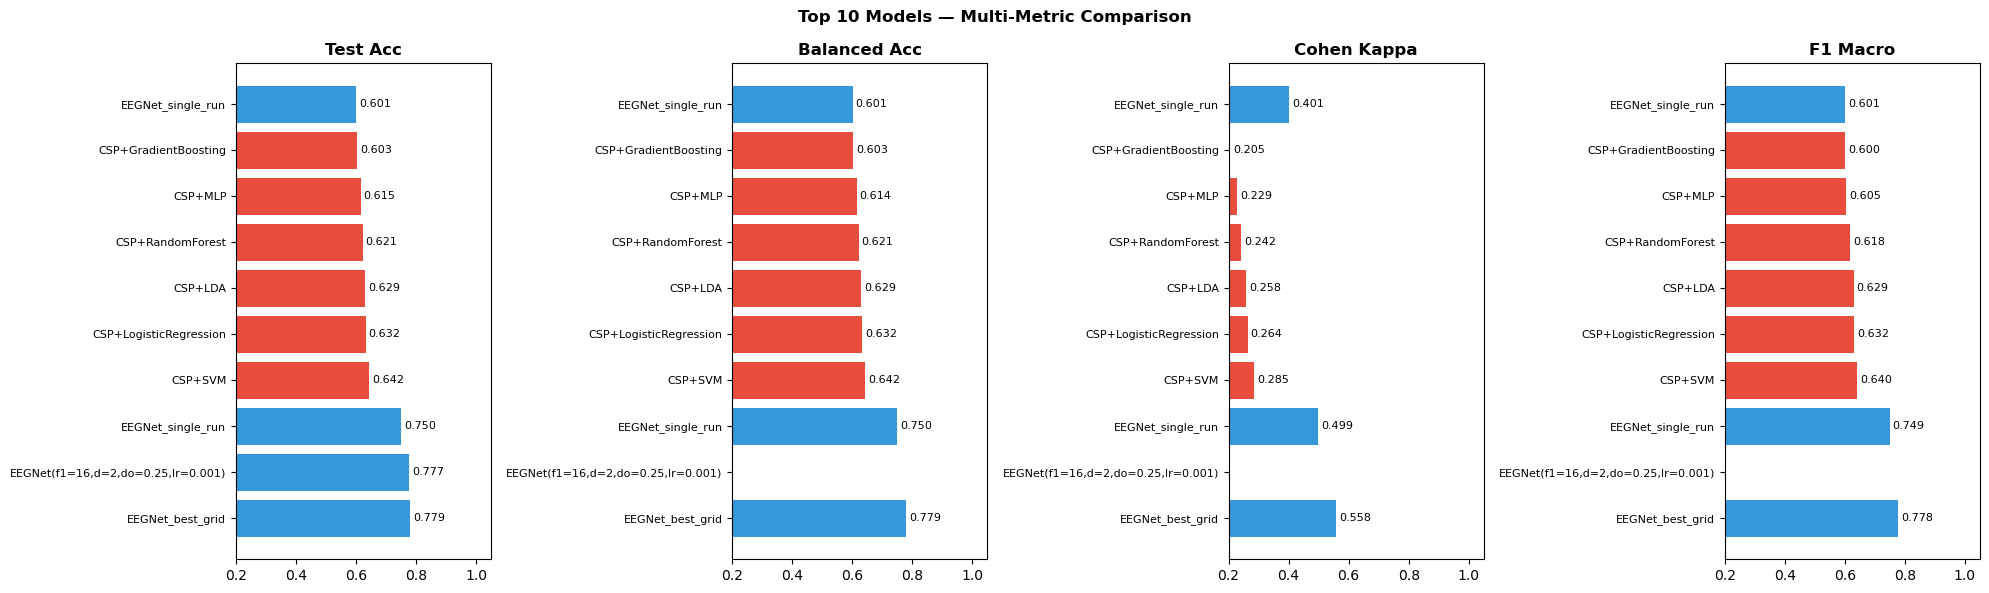

In [84]:
# ── Multi-metric comparison for top models ──
top_n = min(10, len(comp_df))
top = comp_df.head(top_n).copy()

metric_cols = ['Test Acc', 'Balanced Acc', 'Cohen Kappa', 'F1 Macro']
available_cols = [c for c in metric_cols if c in top.columns and top[c].notna().any()]

if len(available_cols) >= 2:
    fig, axes = plt.subplots(1, len(available_cols), figsize=(5*len(available_cols), 6))
    if len(available_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, available_cols):
        vals = top[col].values
        labels = top['Model'].values
        colors = [colors_map.get(a, '#95a5a6') for a in top['Approach']]
        ax.barh(range(len(vals)), vals, color=colors)
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(col, fontweight='bold')
        ax.set_xlim(0.2, 1.05)
        for i, v in enumerate(vals):
            if pd.notna(v):
                ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
    
    plt.suptitle(f'Top {top_n} Models — Multi-Metric Comparison', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 42. Cross-Validation Fold Analysis

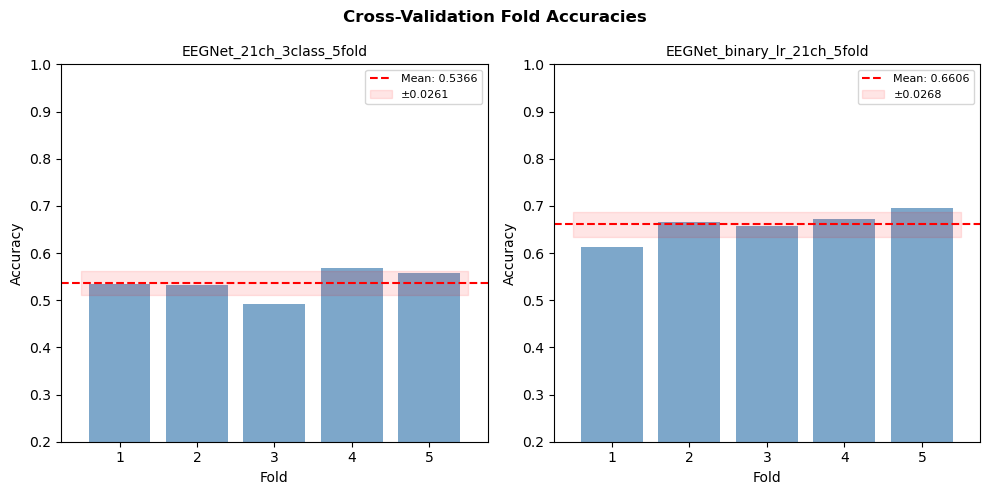

                     CV Run  Folds Mean Acc    Std Min Fold Max Fold
   EEGNet_21ch_3class_5fold      5   0.5366 0.0261   0.4918   0.5674
EEGNet_binary_lr_21ch_5fold      5   0.6606 0.0268   0.6127   0.6945


In [85]:
if CV_DETAILS:
    fig, axes = plt.subplots(1, len(CV_DETAILS), figsize=(5*len(CV_DETAILS), 5))
    if len(CV_DETAILS) == 1:
        axes = [axes]
    
    for ax, (label, details) in zip(axes, CV_DETAILS.items()):
        folds = details['fold_accuracies']
        ax.bar(range(1, len(folds)+1), folds, color='steelblue', alpha=0.7)
        ax.axhline(details['mean_accuracy'], color='red', linestyle='--',
                    label=f"Mean: {details['mean_accuracy']:.4f}")
        ax.fill_between(
            [0.5, len(folds)+0.5],
            details['mean_accuracy'] - details['std_accuracy'],
            details['mean_accuracy'] + details['std_accuracy'],
            color='red', alpha=0.1, label=f"±{details['std_accuracy']:.4f}"
        )
        ax.set_xlabel('Fold')
        ax.set_ylabel('Accuracy')
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8)
        ax.set_ylim(0.2, 1.0)
    
    plt.suptitle('Cross-Validation Fold Accuracies', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print CV details table
    cv_summary = []
    for label, details in CV_DETAILS.items():
        cv_summary.append({
            'CV Run': label,
            'Folds': details['n_splits'],
            'Mean Acc': f"{details['mean_accuracy']:.4f}",
            'Std': f"{details['std_accuracy']:.4f}",
            'Min Fold': f"{min(details['fold_accuracies']):.4f}",
            'Max Fold': f"{max(details['fold_accuracies']):.4f}",
        })
    print(pd.DataFrame(cv_summary).to_string(index=False))
else:
    print("No CV details recorded yet.")


## 43. Per-Class Performance Analysis

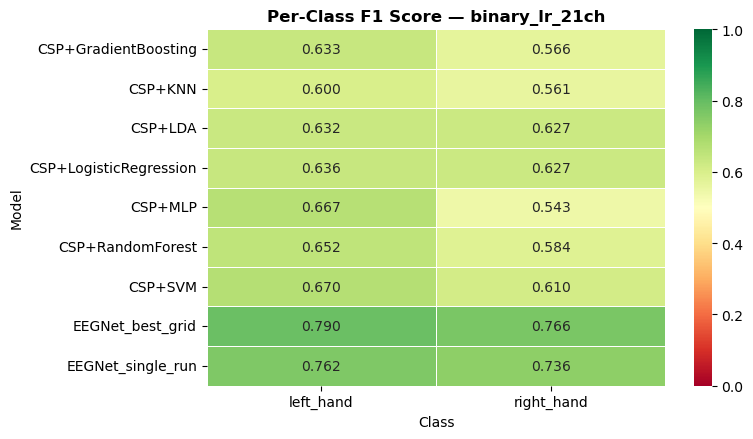

In [86]:
# Gather per-class F1 scores from all registered results
class_perf = []
for r in METRICS_REGISTRY:
    if r.get('f1_per_class'):
        for cls_name, f1_val in r['f1_per_class'].items():
            class_perf.append({
                'Experiment': r['experiment'],
                'Model': r['model_name'],
                'Class': cls_name,
                'F1': f1_val,
            })

if class_perf:
    class_df = pd.DataFrame(class_perf)
    
    # Heatmap: model × class
    for exp in class_df['Experiment'].unique():
        exp_df = class_df[class_df['Experiment'] == exp]
        pivot = exp_df.pivot_table(values='F1', index='Model', columns='Class')
        if len(pivot) > 1:
            plt.figure(figsize=(8, max(3, len(pivot)*0.5)))
            sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                        linewidths=0.5, vmin=0, vmax=1)
            plt.title(f'Per-Class F1 Score — {exp}', fontweight='bold')
            plt.tight_layout()
            plt.show()


## 44. Experiment Summary Table

In [87]:
# Best result per experiment
print("\n" + "="*80)
print("  BEST MODEL PER EXPERIMENT")
print("="*80)

for exp in comp_df['Experiment'].unique():
    exp_best = comp_df[comp_df['Experiment'] == exp].iloc[0]
    print(f"\n  {exp}:")
    print(f"    Best model:      {exp_best['Model']}")
    print(f"    Approach:        {exp_best['Approach']}")
    print(f"    Test Accuracy:   {exp_best['Test Acc']:.4f}")
    if pd.notna(exp_best.get('Balanced Acc')):
        print(f"    Balanced Acc:    {exp_best['Balanced Acc']:.4f}")
    if pd.notna(exp_best.get('Cohen Kappa')):
        print(f"    Cohen's Kappa:   {exp_best['Cohen Kappa']:.4f}")
    if pd.notna(exp_best.get('CV Mean')):
        print(f"    CV:              {exp_best['CV Mean']:.4f} ± {exp_best['CV Std']:.4f}")

print(f"\n{'='*80}")
print(f"  Total registered results: {len(METRICS_REGISTRY)}")
print(f"  Total saved models:       {len(os.listdir(SAVE_DIR))}")
print(f"{'='*80}")



  BEST MODEL PER EXPERIMENT

  binary_lr_21ch:
    Best model:      EEGNet_best_grid
    Approach:        EEGNet
    Test Accuracy:   0.7788
    Balanced Acc:    0.7787
    Cohen's Kappa:   0.5576

  joint_preproc_search:
    Best model:      EEGNet(f1=16,d=2,do=0.25,lr=0.001)
    Approach:        EEGNet
    Test Accuracy:   0.7770

  3class_64ch:
    Best model:      EEGNet_single_run
    Approach:        EEGNet
    Test Accuracy:   0.6009
    Balanced Acc:    0.6009
    Cohen's Kappa:   0.4012

  Total registered results: 11
  Total saved models:       9


## 45. Export Everything

In [88]:
# Final comprehensive export
final_export = {
    'metadata': {
        'notebook': 'MindStride — EEG Motor Imagery Classification',
        'dataset': 'PhysioNet EEG Motor Movement/Imagery (eegmmidb)',
        'runs_used': ['R04', 'R08', 'R12'],
        'task': 'Motor Imagery (left/right fist)',
        'n_subjects': len(raw_data),
        'sfreq': 160,
        'global_split': {
            'train_subjects': sorted(list(GLOBAL_TRAIN_SUBJECTS)),
            'val_subjects': sorted(list(GLOBAL_VAL_SUBJECTS)),
            'test_subjects': sorted(list(GLOBAL_TEST_SUBJECTS)),
        },
        'seed': SEED,
    },
    'results': METRICS_REGISTRY,
    'cv_details': CV_DETAILS,
    'saved_models': os.listdir(SAVE_DIR),
}

export_path = os.path.join(RESULTS_DIR, 'full_experiment_export.json')
with open(export_path, 'w') as f:
    json.dump(final_export, f, indent=2, default=str)

print(f"📦 Full experiment export: {export_path}")
print(f"   {len(METRICS_REGISTRY)} results")
print(f"   {len(CV_DETAILS)} CV runs")
print(f"   {len(os.listdir(SAVE_DIR))} saved models")

# List all saved files
print(f"\n📁 models/")
for fn in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, fn))
    print(f"   {fn} ({size/1024:.1f} KB)")

print(f"\n📁 results/")
for fn in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, fn))
    print(f"   {fn} ({size/1024:.1f} KB)")


📦 Full experiment export: results/full_experiment_export.json
   11 results
   2 CV runs
   9 saved models

📁 models/
   best_ml_binary_lr_21ch.pkl (73.9 KB)
   best_ml_binary_lr_21ch_meta.json (0.3 KB)
   eegnet_21ch_binary_lr_best_grid.pth (50.7 KB)
   eegnet_21ch_binary_lr_best_grid_meta.json (0.2 KB)
   eegnet_21ch_binary_lr_single_run.pth (17.0 KB)
   eegnet_64ch_3class_single_run.pth (20.9 KB)
   eegnet_64ch_3class_single_run_meta.json (0.1 KB)
   global_best_binary_lr.pth (27.7 KB)
   global_best_binary_lr_meta.json (0.4 KB)

📁 results/
   all_metrics.json (24.2 KB)
   cv_details.json (125.0 KB)
   full_experiment_export.json (162.3 KB)
   summary_metrics.csv (1.1 KB)


---
# PART G: FBCSP (Filter Bank CSP) — TODO

The original notebook had a broken FBCSP section (stacking two CSPs sequentially).
A proper FBCSP implementation requires:

1. **Filter bank**: Decompose EEG into 9 sub-bands (4-8, 8-12, ..., 36-40 Hz)
2. **CSP per sub-band**: Apply CSP independently to each filtered signal
3. **Feature selection**: Use mutual information or similar to select the most discriminative CSP features across bands
4. **Classification**: Feed selected features into a classifier (typically LDA or SVM)

```python
# Pseudocode for proper FBCSP:
filter_bands = [(4,8), (8,12), (12,16), (16,20), (20,24), (24,28), (28,32), (32,36), (36,40)]

all_features = []
for low, high in filter_bands:
    X_filtered = butter_bandpass_filter(X, low, high, sfreq=160)
    csp = CSP(n_components=4, reg='ledoit_wolf')
    csp.fit(X_filtered[train_idx], y[train_idx])
    features = csp.transform(X_filtered)
    all_features.append(features)

X_fbcsp = np.concatenate(all_features, axis=1)  # 9 bands × 4 components = 36 features
# Then use mutual information for feature selection
# Then classify with LDA/SVM
```

Consider using `mne.decoding.CSP` with `braindecode` or `pyriemann` for a robust implementation.
